# **IMPORTING LIBRARIES AND PACKAGES**

Import necessary library and initializing the project by connecting it to Google drive where the data set is

In this first cell, Colab will ask you to restart your session. This is necessary to handle correct dependecies between numpy and gensim.

After restarting run the next code cell and it imports everything without errors.

In [ ]:
!pip install numpy==1.23.5 gensim --upgrade --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.2/83.2 kB 5.2 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninstalling wrapt-1.17.2:
      Successfully uninstalled wrapt-1.17.2
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: smart-open
    Found existing installation: smart-open 7.1.0
    Uninstalling smart-open-7.1.0:
      Successfully uninstalled smart-open-7.1.0
  Attempting uninstall: scipy
    Found existing installatio

In [ ]:
# importing library we need.
import numpy as np
from gensim.models import Word2Vec
import pandas as pd
import re
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ParameterGrid
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import KFold
from sklearn.neighbors import NearestNeighbors
import nltk
import math
from collections import Counter
import time
import multiprocessing as mp
from functools import partial
from sklearn.metrics import mean_squared_error

!pip install wikipedia-api
import wikipediaapi

!pip install pyswarm
from pyswarm import pso

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia-api: filename=Wikipedia_API-0.8.1-py3-none-any.whl size=15383 sha256=a073d89bb3390fe8d3bea8f35eb954ec85316aa0d31aaf23e11763509503e716
  Stored in directory: /root/.cache/pip/wheels/0b/0f/39/e8214ec038ccd5aeb8c82b957289f2f3ab2251febeae5c2860
Successfully built wikipedia-api
  Preparing metadata (setup.py) ... done
  Created wheel for pyswarm: filename=pyswarm-0.6-py3-none-any.whl size=4463 sha256=3a989ddbdaf243d5d55962913717c6b18efbfd93617f7d2e0d7c4d9b7b2372af
  Stored in directory: /root/.cache/pip/wheels/bb/4f/ec/8970b83323e16aa95034da175454843947376614d6d5e9627f
Successfully built pyswarm


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

path = 'Colab Notebooks/NAMLprj'

os.chdir(f'/content/drive/MyDrive/{path}')
os.getcwd()

'/content/drive/MyDrive/Colab Notebooks/NAMLprj'

In [ ]:
#should display 'ml-m1' and 'ml-100k'
os.listdir()

['Hybrid_Movie_Recommendation_System_with_User_Parti 1.pdf',
 'ml-100k',
 'ml-1m',
 'Wiki_movie']

# **IMPORTING DATA**

## Ratings
Start importing the dataset relative to the reviews of each user to each film. We defined a function that returns both a df and a matrix with on the row the user and on the column the film

In [ ]:
def load_ratings_df(data_path, separator):
    """
    Loads the user-item rating dataset from the given file path.

    Parameters:
        data_path (str): Path to the dataset file.
        separator (str): The separator used in the dataset file.

    Returns:
        pd.DataFrame: The loaded dataset as a DataFrame.
        np.ndarray: The user-item matrix with ratings.
    """
    try:
        df = pd.read_csv(
            data_path, sep=separator, header=None,
            names=['user_id', 'item_id', 'rating', 'timestamp']
        )
    except FileNotFoundError:
        print(f"Error: File not found at {data_path}")
        return None, None

    # Determine the number of users and items
    n_users = df['user_id'].max()
    n_items = df['item_id'].max()

    # Initialize user-item matrix with 0 (indicating missing ratings)
    user_rating_matrix = np.full((n_users, n_items), 0, dtype=int)

    # Populate the matrix with actual ratings
    for _, row in df.iterrows():
        user_rating_matrix[row['user_id']-1, row['item_id']-1] = row['rating']

    return df, user_rating_matrix

In [ ]:
# Load the datasets
data_path = '/content/drive/MyDrive/Colab Notebooks/NAMLprj/ml-100k/u.data'
rating100k_df, rating100k = load_ratings_df(data_path, '\t')

In [ ]:
# importing 1 milion ratings. do it just at the end since it will take approximately 1 min
data_path = '/content/drive/MyDrive/Colab Notebooks/NAMLprj/ml-1m/ratings.dat'
rating1m_df, rating1m = load_ratings_df(data_path, '::')

<ipython-input-5-7f499af0b83e>:14: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv(


In [ ]:
# Test data to validate correct data loading
# Expected ratings: 3, 3, 1, 2, -1
# Last one is placeholder to say that user dind't evaluate that film
user_ratings = [
    (195, 241),
    (185, 301),
    (21, 376),
    (243, 50),
    (44, 33)
]

expected_ratings = [3, 3, 1, 2, 0]

# Verify each rating matches expected value
for (user, movie), expected in zip(user_ratings, expected_ratings):
    assert rating100k[user, movie] == expected, \
        f"User {user}, movie {movie} - Expected rating {expected}, got {rating100k[user, movie]}"

## Importing Movies df

In [ ]:
# Load the dataset, assuming 'u.item' is in the following path on one drive
data_path = '/content/drive/MyDrive/Colab Notebooks/NAMLprj/ml-100k/u.item'

# Column names based on the dataset description
column_names = [
    'item_id', 'title', 'release_date', 'video_release_date', 'IMDb_URL',
    'unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy',
    'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
    'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]

# The dataset is tab-separated and contains no headers
try:
    film100k_df = pd.read_csv(data_path, sep='|', header=None, names=column_names, encoding='latin-1', index_col='item_id') #do not accept UTF
except FileNotFoundError:
    print("Error: 'u.item' not found in the specified directory.")
    exit()

**Data wrangling** \\
In the readme there is an ambiguity. there is explicitly written there are 2 field: | release date | video release date |.
It seems though they are duplicate. If we try to run this code we can see that there are no items with this field different from null. so we removed this attribute.

In [ ]:
# If it exists (mening is not already dropped)
if 'video_release_date' in film100k_df.columns:
  # Find rows where 'video_release_date' is not null or empty
  non_null_video_release = film100k_df[film100k_df['video_release_date'].notna() & (film100k_df['video_release_date'] != '')]

  # Print the first matching item, if any exist
  if not non_null_video_release.empty:
      print(non_null_video_release.iloc[0])  # Print the first row with a non-null 'video_release_date'
  else:
      print("No items found with a non-null 'video_release_date'.")

No items found with a non-null 'video_release_date'.


In [ ]:
# Drop the 'video_release_date' column if it exists
if 'video_release_date' in film100k_df.columns:
    film100k_df = film100k_df.drop(columns=['video_release_date'])
    print("Column 'video_release_date' dropped successfully.")
else:
    print("Column 'video_release_date' does not exist, no action taken.")

Column 'video_release_date' dropped successfully.


In [ ]:
# List of expected values
expected_values = [
    ["Toy Story (1995)", "01-Jan-1995", "http://us.imdb.com/M/title-exact?Toy%20Story%20(1995)",
     0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],

    ["Perfect Candidate, A (1996)", "27-Sep-1996",
     "http://us.imdb.com/M/title-exact?Perfect%20Candidate,%20A%20(1996)",
     0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],

    ["Intimate Relations (1996)", "09-May-1997",
     "http://us.imdb.com/M/title-exact?Intimate%20Relations%20%281996%29",
     0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],

    ["Scream of Stone (Schrei aus Stein) (1991)", "08-Mar-1996",
     "http://us.imdb.com/M/title-exact?Schrei%20aus%20Stein%20(1991)",
     0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
]

# Assert that each expected row is in the DataFrame
for expected_row in expected_values:
    assert any((film100k_df == expected_row).all(axis=1)), f"Assertion failed: {expected_row} not found in DataFrame"

print("All assertions passed. Expected values are present in the DataFrame.")

All assertions passed. Expected values are present in the DataFrame.


Now that we verified the data is correctly processed for easiness of representation we could change the text of the datas in actual data

In [ ]:
film100k_df['release_date'] = pd.to_datetime(film100k_df['release_date'], format='%d-%b-%Y')

# Verify the conversion
print(film100k_df['release_date'].head())

# Extract release dates for two films
pinocchio_date = film100k_df.loc[film100k_df['title'] == 'Pinocchio (1940)', 'release_date'].iloc[0]
super_mario_date = film100k_df.loc[film100k_df['title'] == 'Super Mario Bros. (1993)', 'release_date'].iloc[0]

# Assert that Pinocchio's release date is earlier than Super Mario Bros.'s release date
assert pinocchio_date < super_mario_date, "Pinocchio (1940) does not have an earlier release date than Super Mario Bros. (1993)"

print("Assertion passed: Pinocchio (1940) was released earlier than Super Mario Bros. (1993).")

item_id
1   1995-01-01
2   1995-01-01
3   1995-01-01
4   1995-01-01
5   1995-01-01
Name: release_date, dtype: datetime64[ns]
Assertion passed: Pinocchio (1940) was released earlier than Super Mario Bros. (1993).


In [ ]:
# Read the data relative to 1 milion movies
film1m = []
data_path = '/content/drive/MyDrive/Colab Notebooks/NAMLprj/ml-1m/movies.dat'
with open(data_path, 'r', encoding='latin-1') as file:
    for line in file:
        line = line.strip()
        if not line:
            continue
        parts = line.split('::')
        if len(parts) != 3:
            continue
        movie_id, title_year, genres_str = parts
        # Extract year using regular expression
        year_match = re.search(r'\((\d{4})\)', title_year)
        if year_match:
            year = int(year_match.group(1))
            title = title_year.strip()
        else:
            year = None
            title = title_year.strip()
        # Split genres into a list
        genres = genres_str.split('|')
        # Append to the data list
        film1m.append({
            'item_id': int(movie_id),
            'title': title,
            'year': year,
            'genres': genres
        })

film1m_df = pd.DataFrame(film1m)

We can check that the genres are the same that are also indicated in the 100 k db so we can use the same binary structure we used before for better adaptability

In [ ]:
# Extract and print all unique genres
unique_genres = film1m_df['genres'].explode().unique()
print("Unique genres:")
for genre in sorted(unique_genres):
    print(genre)

Unique genres:
Action
Adventure
Animation
Children's
Comedy
Crime
Documentary
Drama
Fantasy
Film-Noir
Horror
Musical
Mystery
Romance
Sci-Fi
Thriller
War
Western


effectively they are the same so we use the same structure as 100k reviews.

In [ ]:
# Define the genre names based on the provided index mapping
genre_names = [
    'unknown',        # 0
    'Action',         # 1
    'Adventure',      # 2
    'Animation',      # 3
    "Children's",     # 4
    'Comedy',         # 5
    'Crime',          # 6
    'Documentary',    # 7
    'Drama',          # 8
    'Fantasy',        # 9
    'Film-Noir',      # 10
    'Horror',         # 11
    'Musical',        # 12
    'Mystery',        # 13
    'Romance',        # 14
    'Sci-Fi',         # 15
    'Thriller',       # 16
    'War',            # 17
    'Western'         # 18
]

# Generate binary vectors for each movie's genres
binary_vectors = []
for _, row in film1m_df.iterrows():
    genres = row['genres']
    binary_vector = [0] * len(genre_names)

    if not genres:
        # No genres, set 'unknown' to 1
        binary_vector[0] = 1
    else:
        for genre in genres:
            try:
                idx = genre_names.index(genre)
                binary_vector[idx] = 1
            except ValueError:
                print("error")
                pass
    binary_vectors.append(binary_vector)

# Create DataFrame for binary genres
binary_df = pd.DataFrame(binary_vectors, columns=genre_names)

# Combine with the original DataFrame (excluding the original 'genres' column)
new_df = pd.concat([film1m_df.drop(columns=['genres']), binary_df], axis=1)
film1m_df = new_df

# changing the automatically generated index to the item_id index.
film1m_df = film1m_df.set_index('item_id')

testing

In [ ]:
# Extract generes of Balto
IsForChildren = film1m_df.loc[film1m_df['title'] == 'Balto (1995)', "Children's"].iloc[0]
IsAnimation = film1m_df.loc[film1m_df['title'] == 'Balto (1995)', 'Animation'].iloc[0]
IsComedy = film1m_df.loc[film1m_df['title'] == 'Balto (1995)', 'Comedy'].iloc[0]


# Assert genres
assert IsForChildren == 1, "Balto should be for children"
assert IsAnimation == 1, "Balto should be animated"
assert IsComedy == 0, "Balto is not a comedy"

#There are a lot of film that are presents in both db so it makes sense to see
# if their reppresentation now is the same if we drop release date and year atribute

christmas_carol_100k = film100k_df[film100k_df['title'] == 'Christmas Carol, A (1938)']
christmas_carol_100k = christmas_carol_100k.drop(columns=['release_date', 'IMDb_URL'])
christmas_carol_1m = film1m_df[film1m_df['title'] == 'Christmas Carol, A (1938)']
christmas_carol_1m = christmas_carol_1m.drop(columns=['year'])
are_equal = christmas_carol_100k.equals(christmas_carol_1m)

# Reset the index of both DataFrames to default integer values
christmas_carol_100k = christmas_carol_100k.reset_index(drop=True) # drop=True to avoid old index becoming a column
christmas_carol_1m = christmas_carol_1m.reset_index(drop=True)

are_equal = christmas_carol_100k.equals(christmas_carol_1m)
assert are_equal, "The two DataFrames are not equal"


print("Assertion passed: Balto has not the right genres and Christmas carol is present in a similar way in both db")

Assertion passed: Balto has not the right genres and Christmas carol is present in a similar way in both db


## Importing user

In [ ]:
# Load the dataset, assuming 'u.user' is in the following path on one drive
data_path = '/content/drive/MyDrive/Colab Notebooks/NAMLprj/ml-100k/u.user'

# Column names based on the dataset description
column_names = [
    'user_id', 'age',  'gender' , 'occupation' , 'zip code'
]

# The dataset is tab-separated and contains no headers
try:
    user100k_df = pd.read_csv(data_path, sep='|', header=None, names=column_names, index_col='user_id')
except FileNotFoundError:
    print("Error: 'u.user' not found in the specified directory.")
    exit()

testing user100k_df

**Data Wriangling** \\
in order to be more enligned with the second dataset we decided to map the occupation in the 100k db to a numerical form.  

In [ ]:
# Mapping from first list to second list's numerical representation
occupation_mapping = {
    "other": 0, "none": 0, "not specified": 0,
    "educator": 1, "academic": 1,
    "artist": 2,
    "administrator": 3, "clerical/admin": 3,
    "student": 4, "college/grad student": 4,
    "customer service": 5,
    "doctor": 6, "healthcare": 6, "doctor/health care": 6,
    "executive": 7, "executive/managerial": 7,
    "farmer": 8,
    "homemaker": 9,
    "K-12 student": 10,
    "lawyer": 11,
    "programmer": 12,
    "retired": 13,
    "salesman": 14, "marketing": 14, "sales/marketing": 14,
    "scientist": 15,
    "self-employed": 16,
    "technician": 17, "engineer": 17, "technician/engineer": 17,
    "tradesman/craftsman": 18,
    "unemployed": 19,
    "writer": 20,
    "librarian": 21
}

# Check if the 'occupation' column contains strings (i.e., not already mapped)
if user100k_df["occupation"].dtype == object:  # 'object' dtype typically means strings in pandas
    user100k_df["occupation"] = user100k_df["occupation"].map(occupation_mapping)



In [ ]:
# List of expected values
expected_values = [
    [24, "M", 17, "85711"],
    [21, "M", 4, "48823"],
    [37, "F", 0, "V0R2H"],
    [31, "M", 12, "92660"],
    [32, "F", 20, "33755"],
    [22, "M",  4, "77841"]
]


# Assert that each expected row is in the DataFrame
for expected_row in expected_values:
    assert any((user100k_df == expected_row).all(axis=1)), f"Assertion failed: {expected_row} not found in DataFrame"

print("All assertions passed. Expected values are present in the DataFrame.")

All assertions passed. Expected values are present in the DataFrame.


In [ ]:
# Load the dataset, assuming 'u.user' is in the following path on one drive
data_path = '/content/drive/MyDrive/Colab Notebooks/NAMLprj/ml-1m/users.dat'

# Column names based on the dataset description
column_names = [
    'user_id', 'gender',  'ageRange' , 'occupation' , 'zip code'
]

# The dataset is tab-separated and contains no headers
try:
    user1m_df = pd.read_csv(data_path, sep='::', header=None, names=column_names, index_col='user_id' )
except FileNotFoundError:
    print("Error: 'u.user' not found in the specified directory.")
    exit()

# Swap the 'gender' and 'ageRange' columns to be more coeherent with 100 k version
cols = user1m_df.columns.tolist()
a, b = cols.index('gender'), cols.index('ageRange')
cols[b], cols[a] = cols[a], cols[b]
user1m_df= user1m_df[cols]

<ipython-input-21-12b114cb4afa>:11: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  user1m_df = pd.read_csv(data_path, sep='::', header=None, names=column_names, index_col='user_id' )


To be coherent with the paper we will change the range of 1 million and 100 k dataset to uniform the to the following groups:

| Age in Movielens | Age Level |
|------------------|----------|
| 1-18  (1)          | 1        |
| 18-25  (18)         | 2        |
| 25-35  (25)       | 3        |
| 35-45  (35)         | 4        |
| 45-50  (45)         | 5        |
| 50-56  (50)         | 6        |
| 56+    (56)         | 7        |


In [ ]:
# Define the mapping for user1m_df
age_mapping = {
    1: 1,
    18: 2,
    25: 3,
    35: 4,
    45: 5,
    50: 6,
    56: 7
}

# Apply the mapping to the ageRange column
user1m_df["ageLevel"] = user1m_df["ageRange"].map(age_mapping)

In [ ]:
# Define the bin edges and labels for user100k_df
bins = [1, 18, 25, 35, 45, 50, 56, float('inf')]  # Define the age bins
labels = [1, 2, 3, 4, 5, 6, 7]  # Corresponding ordinal levels

# Apply binning
user100k_df["ageLevel"] = pd.cut(user100k_df["age"], bins=bins, labels=labels, right=False).astype(int)


# **DATASETS**
in the following sections a brief recap on the dataframes and matrix we extracted from the dataset.

## Rating info:
We have both the original complete datasets \\
rating100k_df, rating100k \\
rating1m_df, rating1m \\

---

For each of this category we have both a dataframe reppresentation and a matrix one. For the matrix one we have each row represented by a user, each column a film and at the intersection we have the mark that user gave to that film or -1 if that review is absent.
ATTENTION Notice how the user 1 and movie 1 will be on row 0 and column 0 of our matrix so be cautious about that


In [ ]:
rating100k

array([[5, 3, 4, ..., 0, 0, 0],
       [4, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [5, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 5, 0, ..., 0, 0, 0]])

In [ ]:
rating100k_df

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
...,...,...,...,...
99995,880,476,3,880175444
99996,716,204,5,879795543
99997,276,1090,1,874795795
99998,13,225,2,882399156


In [ ]:
rating1m

array([[5, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [3, 0, 0, ..., 0, 0, 0]])

In [ ]:
rating1m_df

,user_id,item_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


## Film
We have film100k_df and film1m_df. we format both on the the same way having a long array at the end with a 1 in one of the genre iff the film is actually of that genre. In the 100 k we have a complete date while in the 1m version we just have the year extracted in another column other than title for better handling. In the 100k version we also have the IMDb for checking other details.

In [ ]:
film100k_df

,title,release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children's,Comedy,Crime,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
item_id,,,,,,,,,,,,,,,,,,,,,
1,Toy Story (1995),1995-01-01,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
2,GoldenEye (1995),1995-01-01,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,Four Rooms (1995),1995-01-01,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,Get Shorty (1995),1995-01-01,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
5,Copycat (1995),1995-01-01,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1678,Mat' i syn (1997),1998-02-06,http://us.imdb.com/M/title-exact?Mat%27+i+syn+...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1679,B. Monkey (1998),1998-02-06,http://us.imdb.com/M/title-exact?B%2E+Monkey+(...,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
1680,Sliding Doors (1998),1998-01-01,http://us.imdb.com/Title?Sliding+Doors+(1998),0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
film1m_df

,title,year,unknown,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
item_id,,,,,,,,,,,,,,,,,,,,,
1,Toy Story (1995),1995,0,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Jumanji (1995),1995,0,0,1,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,Grumpier Old Men (1995),1995,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
4,Waiting to Exhale (1995),1995,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,Father of the Bride Part II (1995),1995,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3948,Meet the Parents (2000),2000,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3949,Requiem for a Dream (2000),2000,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3950,Tigerland (2000),2000,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## User info
For user info we have user1m_df and user100k_df. We formatted both of them before for having in both case a range of age. In the table we could see the range in both the represenntation that was present in the original db and the ordinal number we used for semplicity and in order to remain coherent to the paper. Another important thing to note is the table below regarding the occupation number and their relative occupation.

| Occupation | Code |
|------------|------|
| other / none / not specified | 0 |
| educator / academic | 1 |
| artist | 2 |
| administrator / clerical/admin | 3 |
| student / college/grad student | 4 |
| customer service | 5 |
| doctor / healthcare / doctor/health care | 6 |
| executive / executive/managerial | 7 |
| farmer | 8 |
| homemaker | 9 |
| K-12 student | 10 |
| lawyer | 11 |
| programmer | 12 |
| retired | 13 |
| salesman / marketing / sales/marketing | 14 |
| scientist | 15 |
| self-employed | 16 |
| technician / engineer / technician/engineer | 17 |
| tradesman/craftsman | 18 |
| unemployed | 19 |
| writer | 20 |
| librarian | 21 |


| Group | Range    |
|-------|----------|
| 1     | Under 18 |
| 2     | 18-24    |
| 3     | 25-34    |
| 4     | 35-44    |
| 5     | 45-49    |
| 6     | 50-55    |
| 7     | 56+      |

In [ ]:
user100k_df

,age,gender,occupation,zip code,ageLevel
user_id,,,,,
1,24,M,17.0,85711,2
2,53,F,0.0,94043,6
3,23,M,20.0,32067,2
4,24,M,17.0,43537,2
5,33,F,0.0,15213,3
...,...,...,...,...,...
939,26,F,4.0,33319,3
940,32,M,3.0,02215,3
941,20,M,4.0,97229,2


In [ ]:
user1m_df

,ageRange,gender,occupation,zip code,ageLevel
user_id,,,,,
1,1,F,10,48067,1
2,56,M,16,70072,7
3,25,M,15,55117,3
4,45,M,7,02460,5
5,25,M,20,55455,3
...,...,...,...,...,...
6036,25,F,15,32603,3
6037,45,F,1,76006,5
6038,56,F,1,14706,7


## Define Train and Test Set

Finally, we will define a train and a test set for our Dataframes and matrices.

Both representations will have the same split and we will create those splits using the *Leave-N-out* approach. This approach will divide the ratings for each user, leaving only the last N ratings for each one of them.

This approach mimics the real behaviour of the system, which is to predict future ratings.

In [ ]:
def split_dataframe_and_matrix(df, rating_matrix, n_test=1):
    """
    Performs a leave-N-out split for each user on both the DataFrame and the user-item matrix.

    Parameters:
        df (pd.DataFrame): The original DataFrame containing the columns ['user_id', 'item_id', 'rating', 'timestamp'].
        rating_matrix (np.ndarray): The user-item rating matrix (users × items).
        n_test (int): Number of ratings to include in the test set for each user.

    Returns:
        train_df (pd.DataFrame): Training ratings.
        test_df (pd.DataFrame): Test ratings.
        train_matrix (np.ndarray): User-item matrix for the training set.
        test_matrix (np.ndarray): User-item matrix for the test set.
    """
    df_sorted = df.sort_values(by=['user_id', 'timestamp'])
    train_rows = []
    test_rows = []

    for user_id, group in df_sorted.groupby('user_id'):
        if len(group) <= n_test:
            train_rows.append(group)
        else:
            test_rows.append(group.tail(n_test))
            train_rows.append(group.iloc[:-n_test])

    train_df = pd.concat(train_rows).reset_index(drop=True)
    test_df = pd.concat(test_rows).reset_index(drop=True)

    # Initialize the empty matrices
    n_users, n_items = rating_matrix.shape
    train_matrix = np.zeros((n_users, n_items), dtype=int)
    test_matrix = np.zeros((n_users, n_items), dtype=int)

    # PPopulate the matrices
    for _, row in train_df.iterrows():
        train_matrix[row['user_id'] - 1, row['item_id'] - 1] = row['rating']

    for _, row in test_df.iterrows():
        test_matrix[row['user_id'] - 1, row['item_id'] - 1] = row['rating']

    return train_df, test_df, train_matrix, test_matrix


In [ ]:
train100k_df, test100k_df, train100k_matrix, test100k_matrix = split_dataframe_and_matrix(rating100k_df, rating100k, n_test=5)

train1m_df, test1m_df, train1m_matrix, test1m_matrix = split_dataframe_and_matrix(rating1m_df, rating1m, n_test=5)

print(f"Train 100K: {len(train100k_df)}, Test 100K: {len(test100k_df)}")
print(f"Train matrix shape: {train100k_matrix.shape}, Test matrix shape: {test100k_matrix.shape}")

print(f"\nTrain 1M: {len(train1m_df)}, Test 1M: {len(test1m_df)}")
print(f"Train matrix shape: {train1m_matrix.shape}, Test matrix shape: {test1m_matrix.shape}")


Train 100K: 95285, Test 100K: 4715
Train matrix shape: (943, 1682), Test matrix shape: (943, 1682)

Train 1M: 970009, Test 1M: 30200
Train matrix shape: (6040, 3952), Test matrix shape: (6040, 3952)


In [ ]:
print("Test 100K dataset dimensions:")
print(f"Number of users (rows): {test100k_matrix.shape[0]}")
print(f"Number of films (columns): {test100k_matrix.shape[1]}")

print("\nTest 1M dataset dimensions:")
print(f"Number of users (rows): {test1m_matrix.shape[0]}")
print(f"Number of films (columns): {test1m_matrix.shape[1]}")


Test 100K dataset dimensions:
Number of users (rows): 943
Number of films (columns): 1682

Test 1M dataset dimensions:
Number of users (rows): 6040
Number of films (columns): 3952


In [ ]:
print('Train matrix')
print(train100k_matrix)
print('\n\nTest matrix')
print(test100k_matrix)

Train matrix
[[5 3 4 ... 0 0 0]
 [4 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 5 0 ... 0 0 0]]


Test matrix
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [5 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


Lastly, we only need a function to compute the RMSE:

In [ ]:
def compute_rmse(predictions, test):
    """
    Computes the Root Mean Squared Error (RMSE) between predicted ratings and ground truth ratings.

    Parameters:
        predictions (np.ndarray or pd.DataFrame):
            - A 2D NumPy array (user-item matrix) with predicted ratings.
            - OR a DataFrame with columns ['user_id', 'item_id', 'rating'] representing predicted ratings.
        test (np.ndarray or pd.DataFrame):
            - If predictions is a NumPy array, test must be a NumPy array of the same shape.
            - If predictions is a DataFrame, test must be a DataFrame with columns ['user_id', 'item_id', 'rating'].

    Returns:
        float: The computed RMSE value.
    """

    if isinstance(predictions, np.ndarray) and isinstance(test, np.ndarray):
        # Mask for test entries (non-zero values)
        mask = test != 0

        # Extract true and predicted ratings only at test positions
        pred_ratings = predictions[mask]
        true_ratings = test[mask]

    elif isinstance(predictions, pd.DataFrame) and isinstance(test, pd.DataFrame):
        # Merge on user_id and item_id to align predictions and ground truth
        merged = pd.merge(test, predictions, on=['user_id', 'item_id'], suffixes=('_true', '_pred'))
        true_ratings = merged['rating_true']
        pred_ratings = merged['rating_pred']

    else:
        raise ValueError("predictions and test must both be either NumPy arrays or Pandas DataFrames of matching format.")

    # Compute RMSE
    rmse = np.sqrt(mean_squared_error(true_ratings, pred_ratings))
    return rmse

# **MATRIX FACTORIZATION USING ALS**

This section is dedicated to the Alternating Least Square Algorithm.

Matrix factorization using ALS aims to transform a sparse matrix into two low-dimensional submatrices: hidden user-feature and hidden item-feature (for us items are movies).

The predicted rating matrix can be calculated by multiplying them.

Here are some websites that explain how the algorithm works:
* https://sophwats.github.io/2018-04-05-gentle-als.html
* https://stanford.edu/~rezab/classes/cme323/S15/notes/lec14.pdf

## Perform the factorization

First let's define the following function to extract the top n recommendations computed by ALS. This will be helpful to show the predictions of the model.

In [ ]:
def get_top_n_recommendations(user_id, user_factors, item_factors, n=5):
    """
      Generates top-N item recommendations for a given user based on latent factor vectors.

      Parameters:
      ----------
      user_id : int
          The ID of the user (1-based index).
      user_factors : np.ndarray
          A 2D NumPy array where each row represents a user's latent factor vector.
      item_factors : np.ndarray
          A 2D NumPy array where each row represents an item's latent factor vector.
      n : int, optional
          The number of top items to recommend (default is 5).

      Returns:
      -------
      List[Tuple[int, float]]
          A list of tuples, where each tuple contains an item index and its corresponding
          scaled recommendation score, sorted from highest to lowest score.
    """
    user_vector = user_factors[user_id - 1]
    scores = np.dot(user_vector, item_factors.T)

    # Apply min-max scaling to scores to have a range between 0 and 5
    min_score = scores.min()
    max_score = scores.max()
    scaled_scores = ((scores - min_score) / (max_score - min_score)) * 5

    top_items = np.argsort(scaled_scores)[::-1][:n]

    return [(item, scaled_scores[item]) for item in top_items]

The best parameters for the two datasets have been previously computed. The process can be seen in the next chapter: *Finding the best parameters for ALS (optional)*

In [ ]:
best_params_100k = {'factors': 7, 'regularization': 5, 'iterations': 15}
best_params_1m = {'factors': 10, 'regularization': 10, 'iterations': 10}

Let's define a function for the ALS algorithm:

In [ ]:
def als(ratings_matrix, factors, regularization, iterations):
    num_users, num_items = ratings_matrix.shape
    R = ratings_matrix.copy()

    # Initialize V randomly
    V = np.random.randint(1, 5, size=(num_items, factors)).astype(np.float64)
    U = np.zeros((num_users, factors)).astype(np.float64)

    I = np.eye(factors)

    for iteration in tqdm(range(iterations)):
        # Update U
        for i in range(num_users):
          idx = R[i, :] > 0 # items rated by user i
          V_i = V[idx]
          R_i = R[i, idx]
          if V_i.shape[0] > 0:
            A = V_i.T @ V_i + regularization * I
            b = V_i.T @ R_i
            U[i] = np.linalg.solve(A, b)

        # Update V
        for j in range(num_items):
          idx = R[:, j] > 0 # users who rated item j
          U_j = U[idx]
          R_j = R[idx, j]
          if U_j.shape[0] > 0:
            A = U_j.T @ U_j + regularization * I
            b = U_j.T @ R_j
            V[j] = np.linalg.solve(A, b)

    return U, V

Let's compute the hidden feature matrices.

In [ ]:
# compute the 100k matrix
U, V = als(train100k_matrix, best_params_100k['factors'], best_params_100k['regularization'], best_params_100k['iterations'])
R1_100k = np.clip(np.dot(U, V.T), 1, 5)
user_hidden_100k = U
item_hidden_100k = V

# compute the 1m matrix
U, V = als(train1m_matrix, best_params_1m['factors'], best_params_1m['regularization'], best_params_1m['iterations'])
R1_1M = np.clip(np.dot(U, V.T), 1, 5)
user_hidden_1m = U
item_hidden_1m = V

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Finally, we use the models to generate and display recommendations for a specific user. We also print the top-rated movies by the user to compare with the recommendations.

The *user_id_to_eval* can be modified to look at different users and their recommendations.

In [ ]:
# Consider the 100k dataset
user_id_to_eval = 9

# get the top 5 rated movies from the rating100k matrix
user_row = rating100k[user_id_to_eval - 1]
top_rated_movies = np.argsort(user_row)[::-1][:5]

print(f'Top 5 rated movies for user {user_id_to_eval}:')
i = 0
for movie_id in top_rated_movies:
    movie_title = film100k_df.loc[movie_id + 1, 'title']
    print(f'{i+1}. {movie_title}, Rating: {user_row[movie_id]}')
    i += 1
    if i >= 5:
        break

# get the corresponding predicted rating
user_row = R1_100k[user_id_to_eval - 1]
print(f'\nPredicted ratings for user {user_id_to_eval}:')
i = 0
for movie_id in top_rated_movies:
    predicted_rating = user_row[movie_id]
    movie_title = film100k_df.loc[movie_id + 1, 'title']
    print(f'{i+1}. {movie_title}, Predicted Rating: {predicted_rating:.2f}')
    i += 1
    if i >= 5:
        break

Top 5 rated movies for user 9:
1. Evil Dead II (1987), Rating: 5
2. Bridges of Madison County, The (1995), Rating: 5
3. Roman Holiday (1953), Rating: 5
4. Star Wars (1977), Rating: 5
5. Shanghai Triad (Yao a yao yao dao waipo qiao) (1995), Rating: 5

Predicted ratings for user 9:
1. Evil Dead II (1987), Predicted Rating: 3.28
2. Bridges of Madison County, The (1995), Predicted Rating: 3.21
3. Roman Holiday (1953), Predicted Rating: 3.76
4. Star Wars (1977), Predicted Rating: 4.11
5. Shanghai Triad (Yao a yao yao dao waipo qiao) (1995), Predicted Rating: 3.46


In [ ]:
# Consider the 1m dataset
user_id_to_eval = 10

# get the top 5 rated movies from the rating1m matrix
user_row = rating1m[user_id_to_eval - 1]
top_rated_movies = np.argsort(user_row)[::-1][:5]

print(f'Top 5 rated movies for user {user_id_to_eval}:')
i = 0
for movie_id in top_rated_movies:
    movie_title = film1m_df.loc[movie_id + 1, 'title']
    print(f'{i+1}. {movie_title}, Rating: {user_row[movie_id]}')
    i += 1
    if i >= 5:
        break

# get the corresponding predicted rating
user_row = R1_1M[user_id_to_eval - 1]
print(f'\nPredicted ratings for user {user_id_to_eval}:')
i = 0
for movie_id in top_rated_movies:
    predicted_rating = user_row[movie_id]
    movie_title = film1m_df.loc[movie_id + 1, 'title']
    print(f'{i+1}. {movie_title}, Predicted Rating: {predicted_rating:.2f}')
    i += 1
    if i >= 5:
        break

Top 5 rated movies for user 10:
1. Toy Story (1995), Rating: 5
2. Close Shave, A (1995), Rating: 5
3. Indiana Jones and the Last Crusade (1989), Rating: 5
4. Being There (1979), Rating: 5
5. Mr. Mom (1983), Rating: 5

Predicted ratings for user 10:
1. Toy Story (1995), Predicted Rating: 4.92
2. Close Shave, A (1995), Predicted Rating: 4.98
3. Indiana Jones and the Last Crusade (1989), Predicted Rating: 4.50
4. Being There (1979), Predicted Rating: 3.84
5. Mr. Mom (1983), Predicted Rating: 4.01


The predicted ratings seem to be quite good, to evaluate the models more we can compute the RMSE on the whole datasets.

In [ ]:
rmse100k = compute_rmse(R1_100k, test100k_matrix)
print(f'RMSE for 100k: {rmse100k}')

rmse1m = compute_rmse(R1_1M, test1m_matrix)
print(f'RMSE for 1m: {rmse1m}')

RMSE for 100k: 1.054843430700217
RMSE for 1m: 0.9458114435766848


This RMSE is great! We can be satisfied of our models.

## What have we obtained

By using ALS, we obtained a factorization of our datasets:

* ***user_hidden_1m, item_hidden_1m***: they represent the predicted ratings of the 1m dataset
* ***user_hidden_100k, item_hidden_100k***: they represent the predicted ratings of the 100k dataset
* ***R1_100k, R1_1m***: they represent the predictions of the two datasets (the ratings are in between 0 and 5, like in the datasets)

We obtained the hidden user-feature matrix and hidden movie-feature matrix. The predicted rating matrix can be calculated by multiplying them. Besides, two hidden feature matrices can be used to obtain predicted matrices of step 2 and step 3.

The weighted hidden user-feature matrix and hidden item-feature matrix can be then utilized to generate the prediction rating matrix 2 and 3 via TOP-N.

Note that when you multiply user-feature and item-feature together you will not recover the exact ratings matrix.



# **Finding the best parameters for ALS (optional)**

This whole section is optional to execute, the training can take up to 20 minutes.

We will work with the 100k and 1m dataset to find the best parameters for the algorithm:

* **factors**: they represent the "hidden-features" that are being extracted from the data
* **regularization**: it represents the regularization parameter for the regression part of the algorithm
* **iterations**: tells how many iterations are to be done in the algorithm

In order to find the best parameters, we choose to use grid optimization. Unfortunately, other methods like gradient descent could not be used since the ALS algorithm is hard to differentiate.

First, we define the implementation of the ALS algorithm:

In [ ]:
def als(ratings_df, factors, regularization, iterations):
    num_users, num_items = ratings_df['user_id'].max(), ratings_df['item_id'].max()

    R = np.zeros((num_users, num_items))
    for row in ratings_df.itertuples():
        R[row.user_id - 1, row.item_id - 1] = row.rating

    # Initialize V randomly
    V = np.random.randint(1, 5, size=(num_items, factors)).astype(np.float64)
    U = np.zeros((num_users, factors)).astype(np.float64)

    I = np.eye(factors)

    for iteration in tqdm(range(iterations)):
        # Update U
        for i in range(num_users):
          idx = R[i, :] > 0 # items rated by user i
          V_i = V[idx]
          R_i = R[i, idx]
          if V_i.shape[0] > 0:
            A = V_i.T @ V_i + regularization * I
            b = V_i.T @ R_i
            U[i] = np.linalg.solve(A, b)

        # Update V
        for j in range(num_items):
          idx = R[:, j] > 0 # users who rated item j
          U_j = U[idx]
          R_j = R[idx, j]
          if U_j.shape[0] > 0:
            A = U_j.T @ U_j + regularization * I
            b = U_j.T @ R_j
            V[j] = np.linalg.solve(A, b)

    return U, V

## Best parameters for the 100k dataset

We will use K-fold cross-validation to find the best parameters. Using this technique will help us prevent overfitting.

In [ ]:
# divide the train set into k=5 subsets
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

train_test_splits = []

for train_index, test_index in kf.split(train100k_df):
    train_set = train100k_df.iloc[train_index]
    test_set = train100k_df.iloc[test_index]

    train_test_splits.append((train_set, test_set))

We need to find the best parameters for ALS, so we define a parameter grid on which we will iterate.

In [ ]:
param_grid = {
    'factors': [10, 20, 40],
    'regularization': [0.1, 1],
    'iterations': [10, 20, 50]
}

grid = list(ParameterGrid(param_grid))

# make 100k into sparse
sparse_user_item = pd.pivot_table(rating100k_df, values='rating', index='user_id', columns='item_id').fillna(0)
user_item_csr = csr_matrix(sparse_user_item)

In [ ]:
# Initialize best model
best_score = float('inf')
best_params = None

scores = []
param_list = []

for params in tqdm(grid):
  print(f'\n\n======================Trying the following parameters: {params}')

  fold_scores = []
  # do k-fold in train_test_splits
  for train_set, test_set in train_test_splits:
    U, V = als(train_set, params['factors'], params['regularization'], params['iterations'])

    R_hat = np.clip(np.dot(U, V.T), 0, 5)

    # compute the rmse
    rmse = compute_rmse(R_hat, test_set)
    print(f'fold RMSE: {rmse}')
    fold_scores.append(rmse)

  print(f'\n\nAverage fold RMSE: {sum(fold_scores) / len(fold_scores)}')

  # update the best model
  if sum(fold_scores) / len(fold_scores) < best_score:
    best_score = sum(fold_scores) / len(fold_scores)
    best_params = params
  scores.append(sum(fold_scores) / len(fold_scores))
  param_list.append(params)


print("Best Parameters:", best_params)
print("Best Score:", best_score)

  0%|          | 0/18 [00:00<?, ?it/s]



======================Trying the following parameters: {'factors': 10, 'iterations': 10, 'regularization': 0.1}


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/18114 [00:00<?, ?it/s]

fold RMSE: 1.1144615520261416


...

  0%|          | 0/18114 [00:00<?, ?it/s]

fold RMSE: 1.2615786043806418


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/18114 [00:00<?, ?it/s]

fold RMSE: 1.2638998619914106


Average fold RMSE: 1.261770074344025
Best Parameters: {'factors': 10, 'iterations': 50, 'regularization': 1}
Best Score: 1.0393136379522478


We plot some results to know where to continue optimizing.

Best parameters: {'factors': 10, 'iterations': 50, 'regularization': 1}
Best score: 1.0393136379522478


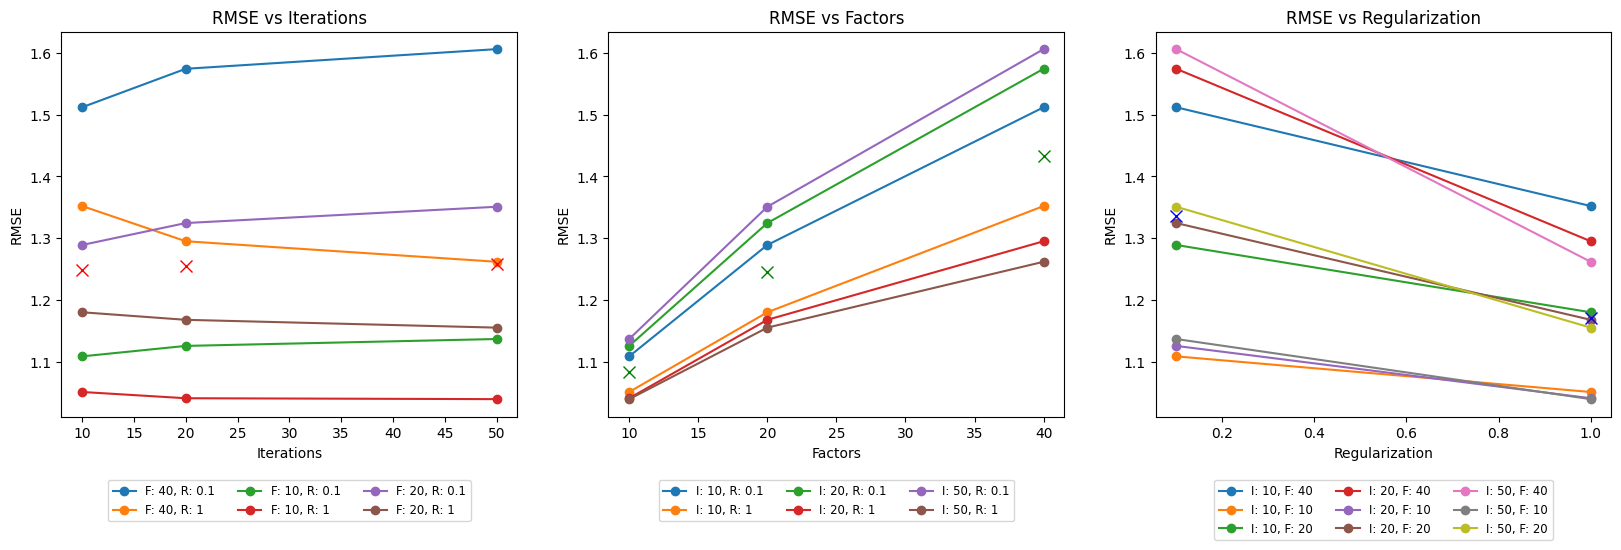

In [ ]:
# plot the scores corresponding to the params
print(f'Best parameters: {best_params}')
print(f'Best score: {best_score}')

fig, axs = plt.subplots(1, 3, figsize=(20, 5))

# initialize lists for computing the mean for different sets of parameters
iterations_list = [params['iterations'] for params in param_list]
factors_list = [params['factors'] for params in param_list]
regularization_list = [params['regularization'] for params in param_list]

# compute the mean for different values of iterations
mean_iters = []
for iter in param_grid['iterations']:
  indices = [i for i, x in enumerate(iterations_list) if x == iter]
  scores_iter = [scores[i] for i in indices]
  mean_iter = sum(scores_iter) / len(scores_iter)
  mean_iters.append(mean_iter)

# divide iterations_list into sets in which the factors and the regularization are the same
unique_factors = set(factors_list)
unique_regularization = set(regularization_list)
iterations_sets = {}
all_scores_sets = {}
for factor in unique_factors:
  for reg in unique_regularization:
    indices = [i for i, x in enumerate(factors_list) if x == factor and regularization_list[i] == reg]
    iterations = [iterations_list[i] for i in indices]
    scores_set = [scores[i] for i in indices]

    iterations_sets.setdefault((factor, reg), []).extend(iterations)
    all_scores_sets.setdefault((factor, reg), []).extend(scores_set)

# plot the evolution of different values of iterations connecting those in which the factors and regularization are the same
for (factor, reg), iterations in iterations_sets.items():
  scores_set = all_scores_sets[(factor, reg)]  # Get scores_set for (factor, reg)
  axs[0].plot(iterations, scores_set, 'o-', label=f'F: {factor}, R: {reg}')

axs[0].plot(param_grid['iterations'], mean_iters, 'rx', markersize=8)
axs[0].set_xlabel('Iterations')
axs[0].set_ylabel('RMSE')
axs[0].set_title(f'RMSE vs Iterations')
axs[0].legend(fontsize='small', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)


# compute the mean for different values of factors
mean_factors = []
for factor in param_grid['factors']:
  indices = [i for i, x in enumerate(factors_list) if x == factor]
  scores_factor = [scores[i] for i in indices]
  mean_factor = sum(scores_factor) / len(scores_factor)
  mean_factors.append(mean_factor)

# divide factors_list into sets in which the iterations and the regularization are the same
factors_sets = {}
all_scores_sets = {}
for iter in param_grid['iterations']:
  for reg in unique_regularization:
    indices = [i for i, x in enumerate(iterations_list) if x == iter and regularization_list[i] == reg]
    factors = [factors_list[i] for i in indices]
    scores_set = [scores[i] for i in indices]
    factors_sets.setdefault((iter, reg), []).extend(factors)
    all_scores_sets.setdefault((iter, reg), []).extend(scores_set)

# plot the evolution of different values of factors connecting those in which the iterations and regularization are the same
for (iter, reg), factors in factors_sets.items():
  scores_set = all_scores_sets[(iter, reg)]  # Get scores_set for (iter, reg)
  axs[1].plot(factors, scores_set, 'o-', label=f'I: {iter}, R: {reg}')

axs[1].plot(param_grid['factors'], mean_factors, 'gx', markersize=8)
axs[1].set_xlabel('Factors')
axs[1].set_ylabel('RMSE')
axs[1].set_title('RMSE vs Factors')
axs[1].legend(fontsize='small', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)


# compute the mean for different values of regularization
mean_regularization = []
for reg in param_grid['regularization']:
  indices = [i for i, x in enumerate(regularization_list) if x == reg]
  scores_reg = [scores[i] for i in indices]
  mean_reg = sum(scores_reg) / len(scores_reg)
  mean_regularization.append(mean_reg)

# divide regularization_list into sets in which the iterations and the factors are the same
regularization_sets = {}
all_scores_sets = {}
for iter in param_grid['iterations']:
  for factor in unique_factors:
    indices = [i for i, x in enumerate(iterations_list) if x == iter and factors_list[i] == factor]
    regularization = [regularization_list[i] for i in indices]
    scores_set = [scores[i] for i in indices]
    regularization_sets.setdefault((iter, factor), []).extend(regularization)
    all_scores_sets.setdefault((iter, factor), []).extend(scores_set)

# plot the evolution of different values of regularization connecting those in which the iterations and factors are the same
for (iter, factor), regularization in regularization_sets.items():
  scores_set = all_scores_sets[(iter, factor)]  # Get scores_set for (iter, factor)
  axs[2].plot(regularization, scores_set, 'o-', label=f'I: {iter}, F: {factor}')

axs[2].plot(param_grid['regularization'], mean_regularization, 'bx', markersize=8)
axs[2].set_xlabel('Regularization')
axs[2].set_ylabel('RMSE')
axs[2].set_title('RMSE vs Regularization')
axs[2].legend(fontsize='small', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

plt.show()

By looking at the plots we can see that:
* we aim for a lower number of factors
* we aim for a higher regularization parameter
* having more iterations can sometimes help, but not always. It is better to stick with a lower value

In [ ]:
param_grid = {
    'factors': [5, 7, 10],
    'regularization': [1, 5, 10],
    'iterations': [10, 15]
}

grid = list(ParameterGrid(param_grid))

In [ ]:
# Initialize best model
best_score = float('inf')
best_params = None

scores = []
param_list = []

for params in tqdm(grid):
  print(f'\n\n======================Trying the following parameters: {params}')

  fold_scores = []
  # do k-fold in train_test_splits
  for train_set, test_set in train_test_splits:
    U, V = als(train_set, params['factors'], params['regularization'], params['iterations'])

    R_hat = np.clip(np.dot(U, V.T), 0, 5)

    # compute the rmse
    rmse = compute_rmse(R_hat, test_set)
    print(f'fold RMSE: {rmse}')
    fold_scores.append(rmse)

  print(f'\n\nAverage fold RMSE: {sum(fold_scores) / len(fold_scores)}')

  # update the best model
  if sum(fold_scores) / len(fold_scores) < best_score:
    best_score = sum(fold_scores) / len(fold_scores)
    best_params = params
  scores.append(sum(fold_scores) / len(fold_scores))
  param_list.append(params)


print("Best Parameters:", best_params)
print("Best Score:", best_score)

  0%|          | 0/18 [00:00<?, ?it/s]



======================Trying the following parameters: {'factors': 5, 'iterations': 10, 'regularization': 1}


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/18114 [00:00<?, ?it/s]

fold RMSE: 0.9816619925338901


...

  0%|          | 0/18114 [00:00<?, ?it/s]

fold RMSE: 0.9764318511734352


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/18114 [00:00<?, ?it/s]

fold RMSE: 0.9669185094984045


Average fold RMSE: 0.9737116483089941
Best Parameters: {'factors': 5, 'iterations': 15, 'regularization': 5}
Best Score: 0.9518516419091831


Best parameters: {'factors': 5, 'iterations': 15, 'regularization': 5}
Best score: 0.9518516419091831


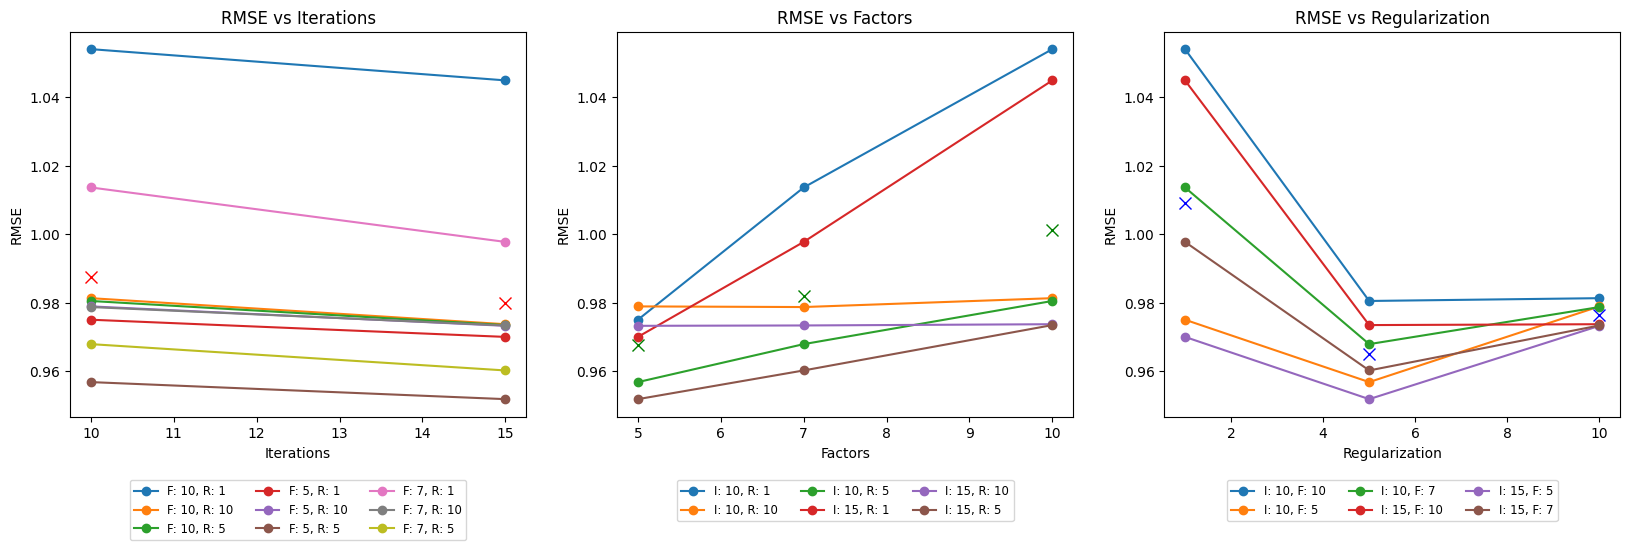

In [ ]:
# plot the scores corresponding to the params
print(f'Best parameters: {best_params}')
print(f'Best score: {best_score}')

fig, axs = plt.subplots(1, 3, figsize=(20, 5))

# initialize lists for computing the mean for different sets of parameters
iterations_list = [params['iterations'] for params in param_list]
factors_list = [params['factors'] for params in param_list]
regularization_list = [params['regularization'] for params in param_list]

# compute the mean for different values of iterations
mean_iters = []
for iter in param_grid['iterations']:
  indices = [i for i, x in enumerate(iterations_list) if x == iter]
  scores_iter = [scores[i] for i in indices]
  mean_iter = sum(scores_iter) / len(scores_iter)
  mean_iters.append(mean_iter)

# divide iterations_list into sets in which the factors and the regularization are the same
unique_factors = set(factors_list)
unique_regularization = set(regularization_list)
iterations_sets = {}
all_scores_sets = {}
for factor in unique_factors:
  for reg in unique_regularization:
    indices = [i for i, x in enumerate(factors_list) if x == factor and regularization_list[i] == reg]
    iterations = [iterations_list[i] for i in indices]
    scores_set = [scores[i] for i in indices]

    iterations_sets.setdefault((factor, reg), []).extend(iterations)
    all_scores_sets.setdefault((factor, reg), []).extend(scores_set)

# plot the evolution of different values of iterations connecting those in which the factors and regularization are the same
for (factor, reg), iterations in iterations_sets.items():
  scores_set = all_scores_sets[(factor, reg)]  # Get scores_set for (factor, reg)
  axs[0].plot(iterations, scores_set, 'o-', label=f'F: {factor}, R: {reg}')

axs[0].plot(param_grid['iterations'], mean_iters, 'rx', markersize=8)
axs[0].set_xlabel('Iterations')
axs[0].set_ylabel('RMSE')
axs[0].set_title(f'RMSE vs Iterations')
axs[0].legend(fontsize='small', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)


# compute the mean for different values of factors
mean_factors = []
for factor in param_grid['factors']:
  indices = [i for i, x in enumerate(factors_list) if x == factor]
  scores_factor = [scores[i] for i in indices]
  mean_factor = sum(scores_factor) / len(scores_factor)
  mean_factors.append(mean_factor)

# divide factors_list into sets in which the iterations and the regularization are the same
factors_sets = {}
all_scores_sets = {}
for iter in param_grid['iterations']:
  for reg in unique_regularization:
    indices = [i for i, x in enumerate(iterations_list) if x == iter and regularization_list[i] == reg]
    factors = [factors_list[i] for i in indices]
    scores_set = [scores[i] for i in indices]
    factors_sets.setdefault((iter, reg), []).extend(factors)
    all_scores_sets.setdefault((iter, reg), []).extend(scores_set)

# plot the evolution of different values of factors connecting those in which the iterations and regularization are the same
for (iter, reg), factors in factors_sets.items():
  scores_set = all_scores_sets[(iter, reg)]  # Get scores_set for (iter, reg)
  axs[1].plot(factors, scores_set, 'o-', label=f'I: {iter}, R: {reg}')

axs[1].plot(param_grid['factors'], mean_factors, 'gx', markersize=8)
axs[1].set_xlabel('Factors')
axs[1].set_ylabel('RMSE')
axs[1].set_title('RMSE vs Factors')
axs[1].legend(fontsize='small', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)


# compute the mean for different values of regularization
mean_regularization = []
for reg in param_grid['regularization']:
  indices = [i for i, x in enumerate(regularization_list) if x == reg]
  scores_reg = [scores[i] for i in indices]
  mean_reg = sum(scores_reg) / len(scores_reg)
  mean_regularization.append(mean_reg)

# divide regularization_list into sets in which the iterations and the factors are the same
regularization_sets = {}
all_scores_sets = {}
for iter in param_grid['iterations']:
  for factor in unique_factors:
    indices = [i for i, x in enumerate(iterations_list) if x == iter and factors_list[i] == factor]
    regularization = [regularization_list[i] for i in indices]
    scores_set = [scores[i] for i in indices]
    regularization_sets.setdefault((iter, factor), []).extend(regularization)
    all_scores_sets.setdefault((iter, factor), []).extend(scores_set)

# plot the evolution of different values of regularization connecting those in which the iterations and factors are the same
for (iter, factor), regularization in regularization_sets.items():
  scores_set = all_scores_sets[(iter, factor)]  # Get scores_set for (iter, factor)
  axs[2].plot(regularization, scores_set, 'o-', label=f'I: {iter}, F: {factor}')

axs[2].plot(param_grid['regularization'], mean_regularization, 'bx', markersize=8)
axs[2].set_xlabel('Regularization')
axs[2].set_ylabel('RMSE')
axs[2].set_title('RMSE vs Regularization')
axs[2].legend(fontsize='small', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

plt.show()

We could go on like this, but we can feel satisfied with what we obtained. In this scenario, we do not want to use too few latent factors, since it may be underfitting our data, so we stick with the following parameters:

* ***Iterations:*** 15
* ***Factors:*** 7
* ***Regularization parameter:*** 5

Now we can test this configuration by training the entire training set with this configuration and compute the rmse with the test set.

In [ ]:
best_params = {'factors': 7, 'regularization': 5, 'iterations': 15}
prediction_matrix_ALS = als(train100k_df, best_params['factors'], best_params['regularization'], best_params['iterations'])

R_hat = np.clip(np.dot(prediction_matrix_ALS[0], prediction_matrix_ALS[1].T), 0, 5)

# compute the rmse
rmse = compute_rmse(R_hat, test100k_df)
print(f'RMSE: {rmse}')

  0%|          | 0/15 [00:00<?, ?it/s]

RMSE: 1.102200612775737


## Best parameters for the 1m dataset

We will use K-fold cross-validation to find the best parameters. Using this technique will help us prevent overfitting.

In [ ]:
# divide the dataset into k=5 subsets
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

train_test_splits = []

for train_index, test_index in kf.split(train1m_df):
    train_set = train1m_df.iloc[train_index]
    test_set = train1m_df.iloc[test_index]

    train_test_splits.append((train_set, test_set))

We need to find the best parameters for ALS, so we define a parameter grid on which we will iterate.

In [ ]:
param_grid = {
    'factors': [20, 40, 80],
    'regularization': [0.1, 1],
    'iterations': [10, 20]
}

grid = list(ParameterGrid(param_grid))

We can now train our model on the selected parameters.

In [ ]:
# Initialize best model
best_score = float('inf')
best_params = None

scores = []
param_list = []

for params in tqdm(grid):
  print(f'\n\n======================Trying the following parameters: {params}')

  fold_scores = []
  # do k-fold in train_test_splits
  for train_set, test_set in train_test_splits:
    U, V = als(train_set, params['factors'], params['regularization'], params['iterations'])

    R_hat = np.clip(np.dot(U, V.T), 0, 5)

    # compute the rmse
    rmse = compute_rmse(R_hat, test_set)
    print(f'fold RMSE: {rmse}')
    fold_scores.append(rmse)

  print(f'\n\nAverage fold RMSE: {sum(fold_scores) / len(fold_scores)}')

  # update the best model
  if sum(fold_scores) / len(fold_scores) < best_score:
    best_score = sum(fold_scores) / len(fold_scores)
    best_params = params
  scores.append(sum(fold_scores) / len(fold_scores))
  param_list.append(params)


print("Best Parameters:", best_params)
print("Best Score:", best_score)

  0%|          | 0/12 [00:00<?, ?it/s]



======================Trying the following parameters: {'factors': 20, 'iterations': 10, 'regularization': 0.1}


  0%|          | 0/10 [00:00<?, ?it/s]

fold RMSE: 0.992534733066664


  0%|          | 0/10 [00:00<?, ?it/s]

...

fold RMSE: 0.9898202371305757


  0%|          | 0/10 [00:00<?, ?it/s]

fold RMSE: 0.9956593672534525


Average fold RMSE: 0.9935787466821981


======================Trying the following parameters: {'factors': 20, 'iterations': 10, 'regularization': 1}


  0%|          | 0/10 [00:00<?, ?it/s]

KeyboardInterrupt: 

Best parameters: {'factors': 20, 'iterations': 20, 'regularization': 1}
Best score: 0.9314347420901724


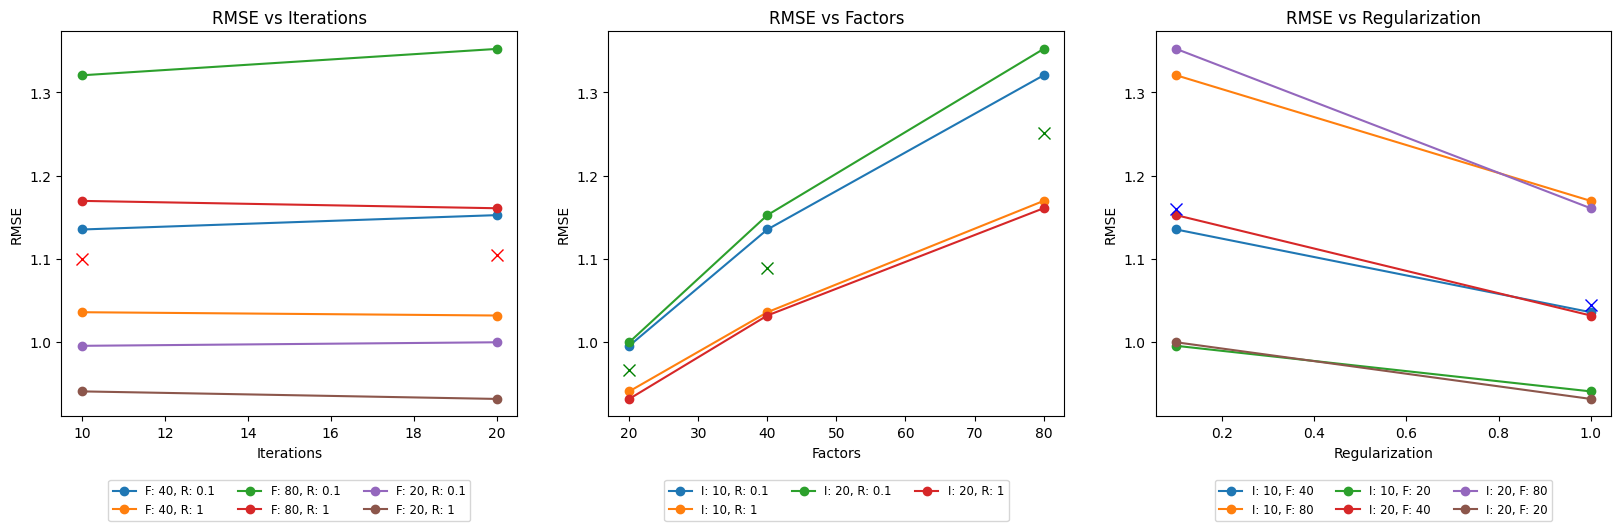

In [ ]:
# plot the scores corresponding to the params
print(f'Best parameters: {best_params}')
print(f'Best score: {best_score}')

fig, axs = plt.subplots(1, 3, figsize=(20, 5))

# initialize lists for computing the mean for different sets of parameters
iterations_list = [params['iterations'] for params in param_list]
factors_list = [params['factors'] for params in param_list]
regularization_list = [params['regularization'] for params in param_list]

# compute the mean for different values of iterations
mean_iters = []
for iter in param_grid['iterations']:
  indices = [i for i, x in enumerate(iterations_list) if x == iter]
  scores_iter = [scores[i] for i in indices]
  mean_iter = sum(scores_iter) / len(scores_iter)
  mean_iters.append(mean_iter)

# divide iterations_list into sets in which the factors and the regularization are the same
unique_factors = set(factors_list)
unique_regularization = set(regularization_list)
iterations_sets = {}
all_scores_sets = {}
for factor in unique_factors:
  for reg in unique_regularization:
    indices = [i for i, x in enumerate(factors_list) if x == factor and regularization_list[i] == reg]
    iterations = [iterations_list[i] for i in indices]
    scores_set = [scores[i] for i in indices]

    iterations_sets.setdefault((factor, reg), []).extend(iterations)
    all_scores_sets.setdefault((factor, reg), []).extend(scores_set)

# plot the evolution of different values of iterations connecting those in which the factors and regularization are the same
for (factor, reg), iterations in iterations_sets.items():
  scores_set = all_scores_sets[(factor, reg)]  # Get scores_set for (factor, reg)
  axs[0].plot(iterations, scores_set, 'o-', label=f'F: {factor}, R: {reg}')

axs[0].plot(param_grid['iterations'], mean_iters, 'rx', markersize=8)
axs[0].set_xlabel('Iterations')
axs[0].set_ylabel('RMSE')
axs[0].set_title(f'RMSE vs Iterations')
axs[0].legend(fontsize='small', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)


# compute the mean for different values of factors
mean_factors = []
for factor in param_grid['factors']:
  indices = [i for i, x in enumerate(factors_list) if x == factor]
  scores_factor = [scores[i] for i in indices]
  mean_factor = sum(scores_factor) / len(scores_factor)
  mean_factors.append(mean_factor)

# divide factors_list into sets in which the iterations and the regularization are the same
factors_sets = {}
all_scores_sets = {}
for iter in param_grid['iterations']:
  for reg in unique_regularization:
    indices = [i for i, x in enumerate(iterations_list) if x == iter and regularization_list[i] == reg]
    factors = [factors_list[i] for i in indices]
    scores_set = [scores[i] for i in indices]
    factors_sets.setdefault((iter, reg), []).extend(factors)
    all_scores_sets.setdefault((iter, reg), []).extend(scores_set)

# plot the evolution of different values of factors connecting those in which the iterations and regularization are the same
for (iter, reg), factors in factors_sets.items():
  scores_set = all_scores_sets[(iter, reg)]  # Get scores_set for (iter, reg)
  axs[1].plot(factors, scores_set, 'o-', label=f'I: {iter}, R: {reg}')

axs[1].plot(param_grid['factors'], mean_factors, 'gx', markersize=8)
axs[1].set_xlabel('Factors')
axs[1].set_ylabel('RMSE')
axs[1].set_title('RMSE vs Factors')
axs[1].legend(fontsize='small', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)


# compute the mean for different values of regularization
mean_regularization = []
for reg in param_grid['regularization']:
  indices = [i for i, x in enumerate(regularization_list) if x == reg]
  scores_reg = [scores[i] for i in indices]
  mean_reg = sum(scores_reg) / len(scores_reg)
  mean_regularization.append(mean_reg)

# divide regularization_list into sets in which the iterations and the factors are the same
regularization_sets = {}
all_scores_sets = {}
for iter in param_grid['iterations']:
  for factor in unique_factors:
    indices = [i for i, x in enumerate(iterations_list) if x == iter and factors_list[i] == factor]
    regularization = [regularization_list[i] for i in indices]
    scores_set = [scores[i] for i in indices]
    regularization_sets.setdefault((iter, factor), []).extend(regularization)
    all_scores_sets.setdefault((iter, factor), []).extend(scores_set)

# plot the evolution of different values of regularization connecting those in which the iterations and factors are the same
for (iter, factor), regularization in regularization_sets.items():
  scores_set = all_scores_sets[(iter, factor)]  # Get scores_set for (iter, factor)
  axs[2].plot(regularization, scores_set, 'o-', label=f'I: {iter}, F: {factor}')

axs[2].plot(param_grid['regularization'], mean_regularization, 'bx', markersize=8)
axs[2].set_xlabel('Regularization')
axs[2].set_ylabel('RMSE')
axs[2].set_title('RMSE vs Regularization')
axs[2].legend(fontsize='small', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

plt.show()

By looking at the plots we can say that:
* the iterations parameter does not really influence the result, so we can stick with 10
* we need to aim for fewer factors, even though this dataset is larger
* we need to aim for a higher regularization parameter

In [ ]:
param_grid = {
    'factors': [10, 15, 20],
    'regularization': [1, 5, 10],
    'iterations': [10]
}

grid = list(ParameterGrid(param_grid))

In [ ]:
# Initialize best model
best_score = float('inf')
best_params = None

scores = []
param_list = []

for params in tqdm(grid):
  print(f'\n\n======================Trying the following parameters: {params}')

  fold_scores = []
  # do k-fold in train_test_splits
  for train_set, test_set in train_test_splits:
    U, V = als(train_set, params['factors'], params['regularization'], params['iterations'])

    R_hat = np.clip(np.dot(U, V.T), 0, 5)

    # compute the rmse
    rmse = compute_rmse(R_hat, test_set)
    print(f'fold RMSE: {rmse}')
    fold_scores.append(rmse)

  print(f'\n\nAverage fold RMSE: {sum(fold_scores) / len(fold_scores)}')

  # update the best model
  if sum(fold_scores) / len(fold_scores) < best_score:
    best_score = sum(fold_scores) / len(fold_scores)
    best_params = params
  scores.append(sum(fold_scores) / len(fold_scores))
  param_list.append(params)


print("Best Parameters:", best_params)
print("Best Score:", best_score)

  0%|          | 0/9 [00:00<?, ?it/s]



======================Trying the following parameters: {'factors': 10, 'iterations': 10, 'regularization': 1}


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/200042 [00:00<?, ?it/s]

fold RMSE: 0.8844858611886817


...

  0%|          | 0/200042 [00:00<?, ?it/s]

fold RMSE: 0.8756896330506269


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/200041 [00:00<?, ?it/s]

fold RMSE: 0.8717038258775888


Average fold RMSE: 0.8741460259678598
Best Parameters: {'factors': 10, 'iterations': 10, 'regularization': 5}
Best Score: 0.868464556498745


Best parameters: {'factors': 10, 'iterations': 10, 'regularization': 5}
Best score: 0.868464556498745


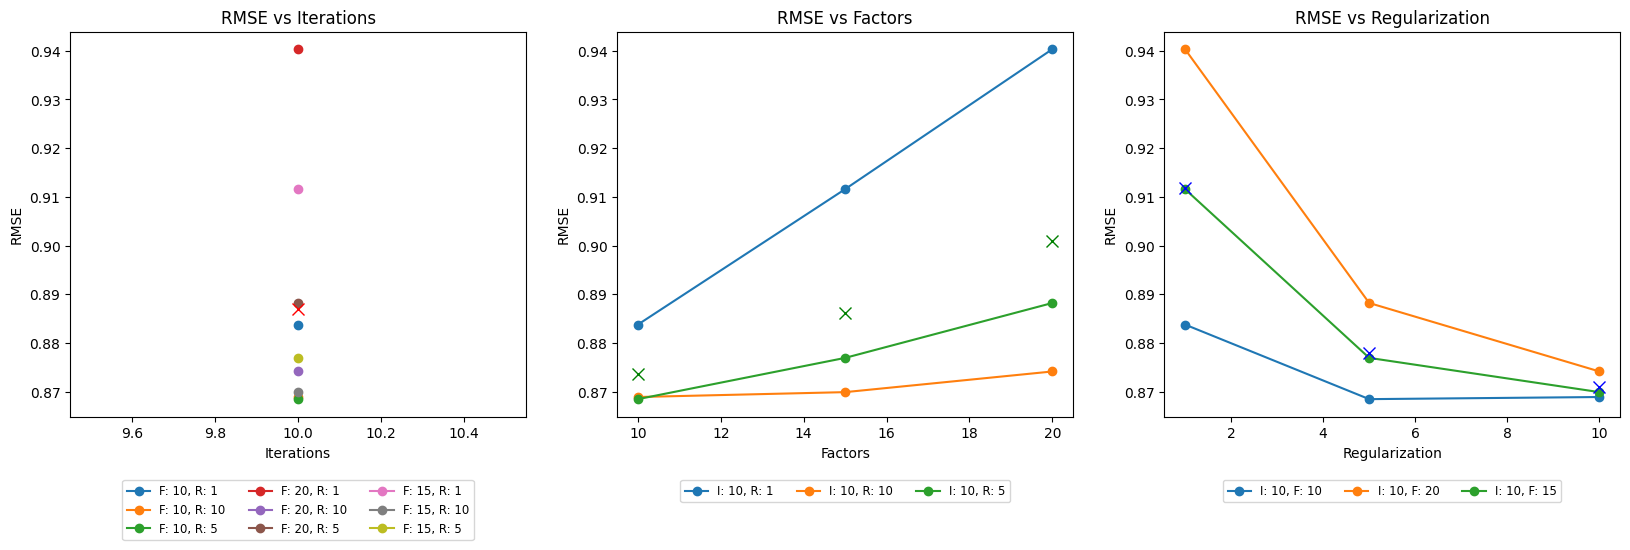

In [ ]:
# plot the scores corresponding to the params
print(f'Best parameters: {best_params}')
print(f'Best score: {best_score}')

fig, axs = plt.subplots(1, 3, figsize=(20, 5))

# initialize lists for computing the mean for different sets of parameters
iterations_list = [params['iterations'] for params in param_list]
factors_list = [params['factors'] for params in param_list]
regularization_list = [params['regularization'] for params in param_list]

# compute the mean for different values of iterations
mean_iters = []
for iter in param_grid['iterations']:
  indices = [i for i, x in enumerate(iterations_list) if x == iter]
  scores_iter = [scores[i] for i in indices]
  mean_iter = sum(scores_iter) / len(scores_iter)
  mean_iters.append(mean_iter)

# divide iterations_list into sets in which the factors and the regularization are the same
unique_factors = set(factors_list)
unique_regularization = set(regularization_list)
iterations_sets = {}
all_scores_sets = {}
for factor in unique_factors:
  for reg in unique_regularization:
    indices = [i for i, x in enumerate(factors_list) if x == factor and regularization_list[i] == reg]
    iterations = [iterations_list[i] for i in indices]
    scores_set = [scores[i] for i in indices]

    iterations_sets.setdefault((factor, reg), []).extend(iterations)
    all_scores_sets.setdefault((factor, reg), []).extend(scores_set)

# plot the evolution of different values of iterations connecting those in which the factors and regularization are the same
for (factor, reg), iterations in iterations_sets.items():
  scores_set = all_scores_sets[(factor, reg)]  # Get scores_set for (factor, reg)
  axs[0].plot(iterations, scores_set, 'o-', label=f'F: {factor}, R: {reg}')

axs[0].plot(param_grid['iterations'], mean_iters, 'rx', markersize=8)
axs[0].set_xlabel('Iterations')
axs[0].set_ylabel('RMSE')
axs[0].set_title(f'RMSE vs Iterations')
axs[0].legend(fontsize='small', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)


# compute the mean for different values of factors
mean_factors = []
for factor in param_grid['factors']:
  indices = [i for i, x in enumerate(factors_list) if x == factor]
  scores_factor = [scores[i] for i in indices]
  mean_factor = sum(scores_factor) / len(scores_factor)
  mean_factors.append(mean_factor)

# divide factors_list into sets in which the iterations and the regularization are the same
factors_sets = {}
all_scores_sets = {}
for iter in param_grid['iterations']:
  for reg in unique_regularization:
    indices = [i for i, x in enumerate(iterations_list) if x == iter and regularization_list[i] == reg]
    factors = [factors_list[i] for i in indices]
    scores_set = [scores[i] for i in indices]
    factors_sets.setdefault((iter, reg), []).extend(factors)
    all_scores_sets.setdefault((iter, reg), []).extend(scores_set)

# plot the evolution of different values of factors connecting those in which the iterations and regularization are the same
for (iter, reg), factors in factors_sets.items():
  scores_set = all_scores_sets[(iter, reg)]  # Get scores_set for (iter, reg)
  axs[1].plot(factors, scores_set, 'o-', label=f'I: {iter}, R: {reg}')

axs[1].plot(param_grid['factors'], mean_factors, 'gx', markersize=8)
axs[1].set_xlabel('Factors')
axs[1].set_ylabel('RMSE')
axs[1].set_title('RMSE vs Factors')
axs[1].legend(fontsize='small', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)


# compute the mean for different values of regularization
mean_regularization = []
for reg in param_grid['regularization']:
  indices = [i for i, x in enumerate(regularization_list) if x == reg]
  scores_reg = [scores[i] for i in indices]
  mean_reg = sum(scores_reg) / len(scores_reg)
  mean_regularization.append(mean_reg)

# divide regularization_list into sets in which the iterations and the factors are the same
regularization_sets = {}
all_scores_sets = {}
for iter in param_grid['iterations']:
  for factor in unique_factors:
    indices = [i for i, x in enumerate(iterations_list) if x == iter and factors_list[i] == factor]
    regularization = [regularization_list[i] for i in indices]
    scores_set = [scores[i] for i in indices]
    regularization_sets.setdefault((iter, factor), []).extend(regularization)
    all_scores_sets.setdefault((iter, factor), []).extend(scores_set)

# plot the evolution of different values of regularization connecting those in which the iterations and factors are the same
for (iter, factor), regularization in regularization_sets.items():
  scores_set = all_scores_sets[(iter, factor)]  # Get scores_set for (iter, factor)
  axs[2].plot(regularization, scores_set, 'o-', label=f'I: {iter}, F: {factor}')

axs[2].plot(param_grid['regularization'], mean_regularization, 'bx', markersize=8)
axs[2].set_xlabel('Regularization')
axs[2].set_ylabel('RMSE')
axs[2].set_title('RMSE vs Regularization')
axs[2].legend(fontsize='small', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

plt.show()

We could go on like this, but we can feel satisfied with what we obtained. We do not want to use fewer factors since it may lead to underfitting, so we stick with the following parameters:

* ***Iterations:*** 10
* ***Factors:*** 10
* ***Regularization parameter:*** 10

## Evaluate the models

The ALS method will be useful for our pipeline especially for the top recommendations, so let's evaluate what we found with regards to the top 10 recommendations.

First, we need to compute the two hidden feature matrices.

In [ ]:
# compute the 100k
best100k_params = {'factors': 7, 'regularization': 5, 'iterations': 15}
U, V = als(train100k_df, best100k_params['factors'], best100k_params['regularization'], best100k_params['iterations'])
rating_100k_ALS = np.clip(np.dot(U, V.T), 0, 5)

# compute the 1m
best1m_params = {'factors': 10, 'regularization': 10, 'iterations': 1}
U, V = als(train1m_df, best1m_params['factors'], best1m_params['regularization'], best1m_params['iterations'])
rating_1m_ALS = np.clip(np.dot(U, V.T), 0, 5)

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Now, we compute the RMSE on the top-10 movies of each user with respect to the 100k dataset

In [ ]:
# extract the top-10 rated movies for every user in the 100k dataset
top_10_rated_movies = np.argsort(rating_100k_ALS, axis=1)[:, -10:]
top_10_rated_movies = pd.DataFrame(top_10_rated_movies, index=rating100k_df['user_id'].unique(), columns=range(10))
# adjust user id and movie id (add 1)
top_10_rated_movies.index = top_10_rated_movies.index + 1
top_10_rated_movies = top_10_rated_movies.map(lambda x: x + 1)
top_10_rated_movies.head()

rmse = 0
for user, movies in tqdm(top_10_rated_movies.iterrows(), total=len(top_10_rated_movies)):
    # Get the actual ratings for the top 10 predicted movies for this user
    real_rating = rating100k_df[(rating100k_df['user_id'] == user) & (rating100k_df['item_id'].isin(movies.values))]['rating'].values

    # If the user has rated any of the top 10 predicted movies, calculate RMSE
    if len(real_rating) > 0:
        # Get the predicted ratings for these movies
        predicted_ratings = [rating_100k_ALS[user - 1, movie - 1] for movie in movies.values if movie in rating100k_df[rating100k_df['user_id'] == user]['item_id'].values]

        # Calculate RMSE for this user and add to the total
        rmse += np.sqrt(np.mean((predicted_ratings - real_rating) ** 2))

rmse /= len(top_10_rated_movies)
print(f'RMSE for the TOP-N on the 100k dataset: {rmse}')

  0%|          | 0/943 [00:00<?, ?it/s]

RMSE for the TOP-N on the 100k dataset: 0.48607124613068764


Now, we compute the RMSE on the top-10 movies of each user with respect to the 1m dataset

In [ ]:
# extract the top-10 rated movies for every user in the 1m dataset
top_10_rated_movies = np.argsort(rating_1m_ALS, axis=1)[:, -10:]
top_10_rated_movies = pd.DataFrame(top_10_rated_movies, index=rating1m_df['user_id'].unique(), columns=range(10))
# adjust user id and movie id (add 1)
top_10_rated_movies.index = top_10_rated_movies.index + 1
top_10_rated_movies = top_10_rated_movies.map(lambda x: x + 1)
top_10_rated_movies.head()

rmse = 0
for user, movies in tqdm(top_10_rated_movies.iterrows(), total=len(top_10_rated_movies)):
    # Get the actual ratings for the top 10 predicted movies for this user
    real_rating = rating1m_df[(rating1m_df['user_id'] == user) & (rating1m_df['item_id'].isin(movies.values))]['rating'].values

    # If the user has rated any of the top 10 predicted movies, calculate RMSE
    if len(real_rating) > 0:
        # Get the predicted ratings for these movies
        predicted_ratings = [rating_1m_ALS[user - 1, movie - 1] for movie in movies.values if movie in rating1m_df[rating1m_df['user_id'] == user]['item_id'].values]

        # Calculate RMSE for this user and add to the total
        rmse += np.sqrt(np.mean((predicted_ratings - real_rating) ** 2))

rmse /= len(top_10_rated_movies)
print(f'RMSE for the TOP-N on the 1m dataset: {rmse}')

  0%|          | 0/6040 [00:00<?, ?it/s]

RMSE for the TOP-N on the 1m dataset: 0.07316923464026762


Now we compute the RMSE on both the whole datasets.

In [ ]:
rmse = compute_rmse(rating_100k_ALS, test100k_df)
print(f'RMSE on the 100k dataset: {rmse}')

rmse = compute_rmse(rating_1m_ALS, test1m_df)
print(f'RMSE on the 1m dataset: {rmse}')

RMSE on the 100k dataset: 1.103836937796878
RMSE on the 1m dataset: 1.1388574863360161


We obtained the following results:
* ***100k dataset RMSE TOP-N***: 0.486
* ***1m dataset RMSE TOP-N***: 0.073
* ***100k whole dataset RMSE***: 1.1
* ***1m whole dataset RMSE***: 1.13


These are great results! We can feel satisfied with our models.

# **DEALING WITH USER COLD START**
In order to deal with user cold start we are going to use user dataframe to compute a similiarity between various user.

To accomplish that first we will also compute the favourite genres of people by picking just the ones that they rated 4 stars or more.

In [ ]:
def get_user_preferred_genres(rating_df, film_df, genre_names, rating_threshold=4):
    """
    Identifies the preferred genres for each user based on ratings above a threshold.
    Includes users with no preferred genres with an empty genre row.

    Args:
        rating_df (pd.DataFrame): DataFrame with user ratings (user_id, item_id, rating).
        film_df (pd.DataFrame): DataFrame with film information including genre columns.
        genre_names (list): List of genre column names in film_df.
        rating_threshold (int): The minimum rating to consider a film "preferred".

    Returns:
        pd.DataFrame: DataFrame with user_id and binary columns for preferred genres,
                      including users with no preferred genres.
    """
    # Filter ratings where rating is above the threshold
    preferredFilms_df = rating_df[rating_df['rating'] >= rating_threshold]

    # Merge with film data to get genres
    merged_df = preferredFilms_df.merge(film_df, on='item_id')

    # Group by user_id and identify preferred genres (binary sum)
    userPreferredGenres_df = merged_df.groupby('user_id')[genre_names].any().astype(int).reset_index()

    # Identify all unique users in the original rating_df
    all_users = rating_df['user_id'].unique()

    # Find users who are in all_users but not in userPreferredGenres_df
    users_with_no_preferred_genres = np.setdiff1d(all_users, userPreferredGenres_df['user_id'].unique())

    # Create a DataFrame for users with no preferred genres
    if len(users_with_no_preferred_genres) > 0:
        no_preferred_genres_df = pd.DataFrame({'user_id': users_with_no_preferred_genres})
        for genre in genre_names:
            no_preferred_genres_df[genre] = 0  # Initialize genre columns with 0

        # Concatenate the two DataFrames
        userPreferredGenres_df = pd.concat([userPreferredGenres_df, no_preferred_genres_df], ignore_index=True)

    return userPreferredGenres_df

In [ ]:
# Example usage with your existing DataFrames and genre_names:
userPreferredGenres100k_df = get_user_preferred_genres(train100k_df, film100k_df, genre_names)
print(userPreferredGenres100k_df)

     user_id  unknown  Action  Adventure  Animation  Children's  Comedy  \
0          1        1       1          1          1           1       1   
1          2        0       1          1          1           1       1   
2          3        0       1          1          0           0       1   
3          4        0       1          1          0           0       1   
4          5        1       1          1          1           1       1   
..       ...      ...     ...        ...        ...         ...     ...   
938      940        0       1          1          1           1       1   
939      941        0       1          1          1           1       1   
940      942        0       1          1          1           1       1   
941      943        0       1          1          1           1       1   
942      685        0       0          0          0           0       0   

     Crime  Documentary  Drama  Fantasy  Film-Noir  Horror  Musical  Mystery  \
0        1         

In [ ]:
# Example usage with your existing DataFrames and genre_names:
userPreferredGenres1m_df = get_user_preferred_genres(train1m_df, film1m_df, genre_names)
print(userPreferredGenres1m_df)

      user_id  unknown  Action  Adventure  Animation  Children's  Comedy  \
0           1        0       1          1          1           1       1   
1           2        0       1          1          0           0       1   
2           3        0       1          1          0           0       1   
3           4        0       1          1          0           1       0   
4           5        0       1          1          1           1       1   
...       ...      ...     ...        ...        ...         ...     ...   
6035     6038        0       1          1          1           0       1   
6036     6039        0       1          1          1           1       1   
6037     6040        0       1          1          1           1       1   
6038     3598        0       0          0          0           0       0   
6039     4486        0       0          0          0           0       0   

      Crime  Documentary  Drama  Fantasy  Film-Noir  Horror  Musical  Mystery  \
0     

We can check what user is missing (there should be 943)

In [ ]:
# Check if all user IDs from 1 to 943 are present in userPreferredGenres_df
user_ids_present = set(userPreferredGenres100k_df['user_id'])
all_user_ids = set(range(1, 944))

missing_user_ids = all_user_ids - user_ids_present

if missing_user_ids:
    print(f"The following user IDs are missing: {missing_user_ids}")
else:
    print("All user IDs from 1 to 943 are present.")


All user IDs from 1 to 943 are present.


In [ ]:
# Check if all user IDs from 1 to 6040 are present in userPreferredGenres_df
user_ids_present = set(userPreferredGenres1m_df['user_id'])
all_user_ids = set(range(1, 6040))

missing_user_ids = all_user_ids - user_ids_present

if missing_user_ids:
    print(f"The following user IDs are missing: {missing_user_ids}")
else:
    print("All user IDs from 1 to 6040 are present.")

All user IDs from 1 to 6040 are present.


We need to compute the similarity matrix between user. Since we have all the user in both the 1 million and 100k training set we will take directly the user1m and user 100k dataframe. First we will need to do a little manipulation on data to respect the formula below with the age ranges presents also in the paper

$$
\text{Sim}_{a,b}^{\text{age}} =
\begin{cases}
\frac{1}{|\text{a}^{\text{age}} - \text{b}^{\text{age}}|}, & \text{if } |\text{a}^{\text{age}} - \text{b}^{\text{age}}| > 1 \\
1, & \text{if } |\text{a}^{\text{age}} - \text{b}^{\text{age}}| \leq 1
\end{cases}
$$


In [ ]:
# We need to create another df called user100k_normalized_age_df where we basically trasform the int number
# in such a way that from 1-18 they gets mapped to 1 etc... (full mapping is described above)

# Create a mapping for age normalization
# Instead of range(56, float('inf')), use a large enough integer as the stop value.
age_mapping = {
    age: group for group, age_range in enumerate([range(1, 19), range(19, 26), range(26, 36), range(36, 46), range(46, 51), range(51, 56), range(56, 1000)], 1) for age in age_range # Changed range(56, float('inf')) to range(56, 1000)
}

# Apply the age mapping to the 'age' column in user100k_df
user100k_normalized_age_df = user100k_df.copy()
user100k_normalized_age_df['age'] = user100k_df['age'].map(age_mapping)


In [ ]:
user100k_normalized_age_df

,age,gender,occupation,zip code,ageLevel
user_id,,,,,
1,2,M,17.0,85711,2
2,6,F,0.0,94043,6
3,2,M,20.0,32067,2
4,2,M,17.0,43537,2
5,3,F,0.0,15213,3
...,...,...,...,...,...
939,3,F,4.0,33319,3
940,3,M,3.0,02215,3
941,2,M,4.0,97229,2


In [ ]:
def calculate_age_similarity(age_df):
    """
    Calculate age similarity matrix between users based on their ages.

    Parameters:
    - age_df: DataFrame containing user IDs as index and 'age' column with normalized ages

    Returns:
    - DataFrame of age similarities between users with user IDs as index and columns
    """
    # Extract 'age' values as a NumPy array
    ages = age_df['age'].values

    # Compute pairwise age differences using broadcasting
    age_diff_matrix = np.abs(ages[:, None] - ages)

    # Initialize the similarity matrix with 1s (default value)
    sim_age = np.ones_like(age_diff_matrix, dtype=float)

    # Apply the formula only where age_diff_matrix > 1
    mask = age_diff_matrix > 1
    sim_age[mask] = 1 / age_diff_matrix[mask]

    # Convert to a DataFrame with same index as input
    sim_age_df = pd.DataFrame(
        sim_age,
        index=age_df.index,
        columns=age_df.index
    )

    return sim_age_df

In [ ]:
sim_age100k = calculate_age_similarity(user100k_normalized_age_df)
sim_age100k.head()

user_id,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
user_id,,,,,,,,,,,,,,,,,,,,,
1,1.00,0.250000,1.00,1.00,1.000000,0.5,0.20,0.5,1.000000,0.250000,...,0.20,0.5,1.00,0.333333,0.5,1.000000,1.000000,1.00,0.333333,1.00
2,0.25,1.000000,0.25,0.25,0.333333,0.5,1.00,0.5,0.333333,1.000000,...,1.00,0.5,0.25,1.000000,0.5,0.333333,0.333333,0.25,1.000000,0.25
3,1.00,0.250000,1.00,1.00,1.000000,0.5,0.20,0.5,1.000000,0.250000,...,0.20,0.5,1.00,0.333333,0.5,1.000000,1.000000,1.00,0.333333,1.00
4,1.00,0.250000,1.00,1.00,1.000000,0.5,0.20,0.5,1.000000,0.250000,...,0.20,0.5,1.00,0.333333,0.5,1.000000,1.000000,1.00,0.333333,1.00
5,1.00,0.333333,1.00,1.00,1.000000,1.0,0.25,1.0,1.000000,0.333333,...,0.25,1.0,1.00,0.500000,1.0,1.000000,1.000000,1.00,0.500000,1.00


In [ ]:
# Create a copy of user1m_df and rename the 'ageLevel' column to 'age'
user1m_normalized_age_df = user1m_df.copy()
user1m_normalized_age_df = user1m_normalized_age_df.rename(columns={'ageLevel': 'age'})

# Now call the function with the modified DataFrame
sim_age1m = calculate_age_similarity(user1m_normalized_age_df)
sim_age1m.head()

user_id,1,2,3,4,5,6,7,8,9,10,...,6031,6032,6033,6034,6035,6036,6037,6038,6039,6040
user_id,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.166667,0.50,0.25,0.50,0.200000,0.333333,0.50,0.50,0.333333,...,1.000000,0.25,0.200000,0.50,0.50,0.50,0.25,0.166667,0.25,0.50
2,0.166667,1.000000,0.25,0.50,0.25,1.000000,0.333333,0.25,0.25,0.333333,...,0.200000,0.50,1.000000,0.25,0.25,0.25,0.50,1.000000,0.50,0.25
3,0.500000,0.250000,1.00,0.50,1.00,0.333333,1.000000,1.00,1.00,1.000000,...,1.000000,0.50,0.333333,1.00,1.00,1.00,0.50,0.250000,0.50,1.00
4,0.250000,0.500000,0.50,1.00,0.50,1.000000,1.000000,0.50,0.50,1.000000,...,0.333333,1.00,1.000000,0.50,0.50,0.50,1.00,0.500000,1.00,0.50
5,0.500000,0.250000,1.00,0.50,1.00,0.333333,1.000000,1.00,1.00,1.000000,...,1.000000,0.50,0.333333,1.00,1.00,1.00,0.50,0.250000,0.50,1.00


$$
\
\text{Sim}_{a,b}^{\text{gender}} =
\begin{cases}
0, & \text{a$^\text{gender}$ $\neq$ b$^\text{gender}$} \\
1, & \text{a$^\text{gender}$ $=$ b$^\text{gender}$}
\end{cases}
\
$$

In [ ]:
def compute_gender_similarity(user_df):
  """
  Computes the pairwise gender similarity between users in a DataFrame.

  Parameters:
      user_df (pd.DataFrame): DataFrame with a 'gender' column and user_id as index.

  Returns:
      pd.DataFrame: A DataFrame representing the pairwise gender similarity matrix.
                    Similarity is 1 if genders are the same, 0 otherwise.
  """
  user_ids = user_df.index.tolist()
  genders = user_df['gender'].values  # Get NumPy array for faster computation

  # Compute pairwise similarity using broadcasting
  sim_gender = pd.DataFrame(
      (genders[:, None] == genders).astype(int),
      index=user_ids,
      columns=user_ids
  )
  return sim_gender


In [ ]:
# Example usage with user100k_df
sim_gender100k = compute_gender_similarity(user100k_df)
print(sim_gender100k.head())

   1    2    3    4    5    6    7    8    9    10   ...  934  935  936  937  \
1    1    0    1    1    0    1    1    1    1    1  ...    1    1    1    1   
2    0    1    0    0    1    0    0    0    0    0  ...    0    0    0    0   
3    1    0    1    1    0    1    1    1    1    1  ...    1    1    1    1   
4    1    0    1    1    0    1    1    1    1    1  ...    1    1    1    1   
5    0    1    0    0    1    0    0    0    0    0  ...    0    0    0    0   

   938  939  940  941  942  943  
1    0    0    1    1    0    1  
2    1    1    0    0    1    0  
3    0    0    1    1    0    1  
4    0    0    1    1    0    1  
5    1    1    0    0    1    0  

[5 rows x 943 columns]


In [ ]:
# Example usage with user100k_df
sim_gender1m = compute_gender_similarity(user1m_df)
print(sim_gender1m.head())

   1     2     3     4     5     6     7     8     9     10    ...  6031  \
1     1     0     0     0     0     1     0     0     0     1  ...     1   
2     0     1     1     1     1     0     1     1     1     0  ...     0   
3     0     1     1     1     1     0     1     1     1     0  ...     0   
4     0     1     1     1     1     0     1     1     1     0  ...     0   
5     0     1     1     1     1     0     1     1     1     0  ...     0   

   6032  6033  6034  6035  6036  6037  6038  6039  6040  
1     0     0     0     1     1     1     1     1     0  
2     1     1     1     0     0     0     0     0     1  
3     1     1     1     0     0     0     0     0     1  
4     1     1     1     0     0     0     0     0     1  
5     1     1     1     0     0     0     0     0     1  

[5 rows x 6040 columns]


We will compute the jaccard similarity for genres'preference:

$$
\
\text{Sim}_{a,b}^{\text{genre}} = \frac{\text{a$^\text{genre}$ $\cap$ b$^\text{genre}$}}{\text{a$^\text{genre}$ $\cup$ b$^\text{genre}$}}
\
$$

In [ ]:
def compute_genre_similarity(userPreferredGenres_df):
    """
    Computes Jaccard similarity between users based on their preferred genres.

    Parameters:
        userPreferredGenres_df (pd.DataFrame): DataFrame with user preferences,
                                              including 'user_id' and binary genre columns.

    Returns:
        pd.DataFrame: DataFrame representing the user-user Jaccard similarity matrix
                      based on genres, with user_id as both index and columns.
    """
    # Extract genre data as a NumPy array
    # Assuming genre_names is defined elsewhere in your code and contains the list of genre column names
    genre_matrix = userPreferredGenres_df[genre_names].values.astype(int)

    # Compute pairwise intersections (dot product of genre vectors)
    intersection = genre_matrix @ genre_matrix.T

    # Compute sum of genres for each user
    sum_a = genre_matrix.sum(axis=1)

    # Compute pairwise unions using broadcasting: sum_a[i] + sum_a[j] - intersection[i,j]
    union = sum_a[:, None] + sum_a - intersection

    # Compute Jaccard similarity (intersection / union), avoid division by zero
    jaccard = np.divide(intersection, union, where=(union != 0), out=np.zeros_like(intersection, dtype=float))

    # Explicitly set diagonal to 1 (users are identical to themselves)
    np.fill_diagonal(jaccard, 1.0)

    # Create DataFrame with user IDs
    sim_genre = pd.DataFrame(
        jaccard,
        index=userPreferredGenres_df['user_id'].unique(),
        columns=userPreferredGenres_df['user_id'].unique()
    )

    return sim_genre

In [ ]:
sim_genre100k = compute_genre_similarity(userPreferredGenres100k_df)

# Display the result
print(sim_genre100k.head())

        1         2         3         4         5         6         7    \
1  1.000000  0.684211  0.473684  0.684211  0.947368  0.894737  0.947368   
2  0.684211  1.000000  0.692308  0.625000  0.722222  0.764706  0.722222   
3  0.473684  0.692308  1.000000  0.692308  0.500000  0.529412  0.500000   
4  0.684211  0.625000  0.692308  1.000000  0.631579  0.764706  0.722222   
5  0.947368  0.722222  0.500000  0.631579  1.000000  0.842105  0.894737   

        8         9         10   ...       935       936       937       938  \
1  0.631579  0.473684  0.947368  ...  0.526316  0.789474  0.684211  0.842105   
2  0.666667  0.692308  0.722222  ...  0.769231  0.750000  0.857143  0.812500   
3  0.615385  0.636364  0.500000  ...  0.900000  0.600000  0.692308  0.562500   
4  0.666667  0.571429  0.722222  ...  0.769231  0.866667  0.733333  0.705882   
5  0.666667  0.500000  0.894737  ...  0.555556  0.736842  0.631579  0.888889   

        939       940       941       942       943  685  
1  0.7368

In [ ]:
sim_genre1m = compute_genre_similarity(userPreferredGenres1m_df)

# Display the result
print(sim_genre1m.head())

       1         2         3         4         5         6         7     \
1  1.000000  0.562500  0.600000  0.666667  0.666667  0.785714  0.600000   
2  0.562500  1.000000  0.642857  0.600000  0.705882  0.600000  0.769231   
3  0.600000  0.642857  1.000000  0.769231  0.555556  0.642857  0.692308   
4  0.666667  0.600000  0.769231  1.000000  0.611111  0.600000  0.642857   
5  0.666667  0.705882  0.555556  0.611111  1.000000  0.705882  0.647059   

       8         9         10    ...      6033      6034      6035      6036  \
1  0.625000  0.647059  0.764706  ...  0.733333  0.312500  0.705882  0.722222   
2  0.785714  0.800000  0.705882  ...  0.666667  0.538462  0.750000  0.666667   
3  0.714286  0.529412  0.647059  ...  0.846154  0.357143  0.687500  0.611111   
4  0.666667  0.588235  0.705882  ...  0.923077  0.428571  0.750000  0.666667   
5  0.764706  0.882353  0.888889  ...  0.666667  0.470588  0.833333  0.944444   

       6037      6038      6039      6040  3598  4486  
1  0.722222 

$$
\
\text{Sim}_{a,b}^{\text{occupation}} =
\begin{cases}
0, & \text{a$^\text{occupation}$ $\neq$ b$^\text{occupation}$} \\
1, & \text{a$^\text{occupation}$ $=$ b$^\text{occupation}$}
\end{cases}
\
$$

In [ ]:
def compute_occupation_similarity(user_df):
  """
  Computes a pairwise similarity matrix based on user occupation.

  Args:
    user_df: A pandas DataFrame with user IDs as index and an 'occupation' column.

  Returns:
    A pandas DataFrame representing the occupation similarity matrix, where
    sim_matrix[i, j] is 1 if user i and user j have the same occupation, and 0 otherwise.
  """
  # Extract user IDs and occupation
  user_ids = user_df.index.tolist()
  occupations = user_df['occupation'].values  # Get NumPy array for faster computation

  # Compute pairwise similarity using broadcasting
  sim_occupation = pd.DataFrame(
      (occupations[:, None] == occupations).astype(int),
      index=user_ids,
      columns=user_ids
  )

  return sim_occupation

In [ ]:
sim_occupation_matrix100k = compute_occupation_similarity(user100k_df)
sim_occupation_matrix100k.head()

,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
1,1,0,0,1,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0
2,0,1,0,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,1,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0
5,0,1,0,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [ ]:
sim_occupation_matrix1m = compute_occupation_similarity(user1m_df)
sim_occupation_matrix1m.head()

,1,2,3,4,5,6,7,8,9,10,...,6031,6032,6033,6034,6035,6036,6037,6038,6039,6040
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
5,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


$$
\begin{array}{c|c}
\text{Sim}_{(a,b)} \text{UI}  = L_1 \text{Sim}_{a,b}^{age} + L_2 \text{Sim}_{a,b}^{gender} + L_3 \text{Sim}_{a,b}^{genre} +  L_4 \text{Sim}_{a,b}^{occupation}\\
\end{array}
$$

In [ ]:
# User average ratings
user_avg_ratings100k = train100k_df.groupby('user_id')['rating'].mean()

# HFM similarity matrix between all the possible users.
hfm_sim100k = cosine_similarity(user_hidden_100k)

print(len(user_avg_ratings100k))

943


In [ ]:
user_avg_ratings100k

,rating
user_id,
1,3.621723
2,3.807018
3,2.673469
4,4.526316
5,2.917647
...,...
939,4.386364
940,3.470588
941,4.058824


In [ ]:
print(hfm_sim100k.shape)

(943, 943)


In [ ]:
# User average ratings
user_avg_ratings1m = train1m_df.groupby('user_id')['rating'].mean()

# HFM similarity matrix between all the possible users.
hfm_sim1m = cosine_similarity(user_hidden_1m)

print(len(user_avg_ratings1m))

6040


In [ ]:
user_avg_ratings1m

,rating
user_id,
1,4.187500
2,3.750000
3,3.869565
4,4.125000
5,3.155440
...,...
6036,3.315968
6037,3.715736
6038,3.866667


In [ ]:
print(hfm_sim1m.shape)

(6040, 6040)


After the train (covered in the next section) we can come to the discover of the factor alfa, beta, L1, L2 and L3.

In [ ]:
L1=0.31
L2=0.27
L3=0.42
alpha=0.7
beta=0.3

In [ ]:
def compute_full_rating_matrix(full_rating_matrix, L1, L2, alpha, sim_age, sim_genre, sim_gender, hfm_sim, user_avg_ratings):
    """
    Compute the complete matrix of predicted ratings using best parameters.

    Parameters:
        full_rating_matrix (np.ndarray): The original full rating matrix (e.g., rating100k or rating1m).
        L1, L2, alpha: Optimal parameters from PSO

    Returns:
        predicted_matrix: A matrix of predicted ratings for all user-item pairs
    """
    print("Computing full prediction matrix...")
    start_time = time.time()

    # Calculate derived parameters
    L3 = 1 - L1 - L2
    beta = 1 - alpha

    # Compute combined similarity matrix
    print("Computing combined similarity matrix...")
    # Convert to NumPy arrays if they aren't already
    sim_age_np = sim_age.to_numpy() if hasattr(sim_age, 'to_numpy') else sim_age
    sim_gender_np = sim_gender.to_numpy() if hasattr(sim_gender, 'to_numpy') else sim_gender
    sim_genre_np = sim_genre.to_numpy() if hasattr(sim_genre, 'to_numpy') else sim_genre
    hfm_sim_np = hfm_sim.to_numpy() if hasattr(hfm_sim, 'to_numpy') else hfm_sim

    ui_sim = L1 * sim_age_np + L2 * sim_gender_np + L3 * sim_genre_np
    combined_sim = alpha * hfm_sim_np + beta * ui_sim

    # Dimensions of the rating matrix
    num_users, num_items = full_rating_matrix.shape

    # Precompute item_rated_users using the provided full_rating_matrix
    item_rated_users = {}
    for item_idx in range(num_items):
        rated_users = np.where(full_rating_matrix[:, item_idx] != 0)[0]
        item_rated_users[item_idx] = rated_users

    # Ensure user_avg_ratings is in the right format
    user_avg_ratings_array = user_avg_ratings.sort_index().to_numpy() if hasattr(user_avg_ratings, 'sort_index') else user_avg_ratings

    # Initialize prediction matrix (will store all predictions)
    predicted_matrix = np.zeros((num_users, num_items))

    # Fill in the matrix with user average ratings as default
    for user_idx in range(num_users):
        if user_idx < len(user_avg_ratings_array):
            predicted_matrix[user_idx, :] = user_avg_ratings_array[user_idx]
        else:
            predicted_matrix[user_idx, :] = np.mean(user_avg_ratings_array)

    # Compute predictions for each item (item-centric approach is more efficient)
    print(f"Computing predictions for {num_items} items...")
    for item_idx in tqdm(range(num_items)):
        # Get users who rated this item
        rated_user_indices = item_rated_users.get(item_idx, np.array([]))

        if len(rated_user_indices) == 0:
            continue  # Skip if no users rated this item

        # For each user who hasn't rated this item, predict rating
        for user_idx in range(num_users):
            # Skip if user is out of bounds (though this shouldn't happen in practice)
            if user_idx >= combined_sim.shape[0]:
                continue

            # Get similarities between active user and users who rated this item
            similarities = combined_sim[user_idx, rated_user_indices]

            # Filter valid similarities and get top neighbors
            valid_mask = (similarities != -np.inf) & (~np.isnan(similarities))
            valid_sim = similarities[valid_mask]
            valid_neighbors = rated_user_indices[valid_mask]

            if len(valid_neighbors) == 0:
                continue  # Skip if no valid neighbors

            # Get top N neighbors
            top_n = min(5, len(valid_neighbors))
            if len(valid_neighbors) > top_n:
                top_indices = np.argpartition(-valid_sim, top_n)[:top_n]
                top_neighbors = valid_neighbors[top_indices]
                top_similarities = valid_sim[top_indices]
            else:
                top_neighbors = valid_neighbors
                top_similarities = valid_sim

            # Calculate prediction using the provided full_rating_matrix
            active_mean = user_avg_ratings_array[user_idx]
            neighbor_means = user_avg_ratings_array[top_neighbors]
            neighbor_ratings = full_rating_matrix[top_neighbors, item_idx] # Use full_rating_matrix here
            rating_deltas = neighbor_ratings - neighbor_means

            weighted_sum = np.sum(top_similarities * rating_deltas)
            sim_sum = np.sum(top_similarities)

            if sim_sum > 0:
                prediction = active_mean + (weighted_sum / sim_sum)
                # Clip prediction to valid rating range (e.g., 1-5)
                prediction = np.clip(prediction, 1, 5)
                predicted_matrix[user_idx, item_idx] = prediction

    elapsed = time.time() - start_time
    print(f"Full prediction matrix computed in {elapsed:.2f} seconds")

    return predicted_matrix

In [ ]:
predicted_matrix_user_cold_start100k=compute_full_rating_matrix(train100k_matrix,L1,L2,alpha,sim_age100k, sim_genre100k, sim_gender100k, hfm_sim100k, user_avg_ratings100k)

Computing full prediction matrix...
Computing combined similarity matrix...
Computing predictions for 1682 items...


  0%|          | 0/1682 [00:00<?, ?it/s]

Full prediction matrix computed in 85.27 seconds


In [ ]:
R2_100k=predicted_matrix_user_cold_start100k

In [ ]:
predicted_matrix_user_cold_start1m=compute_full_rating_matrix( train1m_matrix,L1, L2, alpha,sim_age1m, sim_genre1m, sim_gender1m, hfm_sim1m, user_avg_ratings1m)

Computing full prediction matrix...
Computing combined similarity matrix...
Computing predictions for 3952 items...


  0%|          | 0/3952 [00:00<?, ?it/s]

Full prediction matrix computed in 1243.19 seconds


In [ ]:
R2_1m=predicted_matrix_user_cold_start1m

In [ ]:
rmse_100k_cold_start = compute_rmse(predicted_matrix_user_cold_start100k, test100k_matrix)
print(f'RMSE for user cold start 100k: {rmse_100k_cold_start}')

rmse_1m_cold_start = compute_rmse(predicted_matrix_user_cold_start1m, test1m_matrix)
print(f'RMSE for user cold start 1m: {rmse_1m_cold_start}')

RMSE for user cold start 100k: 1.0579500865470957
RMSE for user cold start 1m: 0.9756784224197641


# **Finding the best parameter for User cold start (optional)**

Training of L1, L2, alfa parameters using a grid optimizer. It seems very flat the region but i could be wrong

In [ ]:
# --------------------------------------------------
# GLOBAL VARIABLES (UPDATED)
# --------------------------------------------------
# Precompute item_rated_users: a dictionary where each key is an item index (0-based)
# and the value is an array of user indices (0-based) who have rated that item.
item_rated_users100k = {}
for item_idx in range(train100k_matrix.shape[1]):
    rated_users100k = np.where(train100k_matrix[:, item_idx] != 0)[0]
    item_rated_users100k[item_idx] = rated_users100k

# Convert user_avg_ratings to a 0-based numpy array for faster access
user_avg_ratings_array = user_avg_ratings100k.sort_index().to_numpy()
# --------------------------------------------------

Training using PSO. We used just the 100k dataset for the training becaue it was already taking too long and we don't have the necessary computational power to obtain L1,L2,L3, alfa and beta starting from the 1m dataset. With this being said we are happy with the result we got since they are pretty close to the one of the paper.

In [ ]:
def predict_rating_vectorized(user_item_pairs, combined_sim, user_avg_ratings_array, rating_matrix, item_rated_users, top_n=5):
    """Vectorized prediction for multiple user-item pairs."""
    predictions = np.zeros(len(user_item_pairs))

    for i, (user_id, item_id) in enumerate(user_item_pairs):
        user_idx = user_id - 1  # 0-based index
        item_idx = item_id - 1  # 0-based index

        # Handle edge cases
        if user_idx >= len(user_avg_ratings_array) or user_idx >= combined_sim.shape[0]:
            predictions[i] = user_avg_ratings_array[user_idx] if user_idx < len(user_avg_ratings_array) else np.mean(user_avg_ratings_array)
            continue

        active_mean = user_avg_ratings_array[user_idx]

        # Get users who rated this item
        candidate_indices = item_rated_users.get(item_idx, np.array([]))
        candidate_indices = candidate_indices[candidate_indices != user_idx]

        if len(candidate_indices) == 0:
            predictions[i] = active_mean
            continue

        # Get similarities
        sim_vals = combined_sim[user_idx, candidate_indices]

        # Select top N neighbors
        if len(candidate_indices) > top_n:
            top_indices = np.argpartition(-sim_vals, top_n)[:top_n]
            top_candidates = candidate_indices[top_indices]
            sim_vals = sim_vals[top_indices]
        else:
            top_candidates = candidate_indices

        # Filter valid similarities
        valid_mask = (sim_vals != -np.inf) & (~np.isnan(sim_vals))
        sim_vals = sim_vals[valid_mask]
        top_candidates = top_candidates[valid_mask]

        if len(top_candidates) == 0:
            predictions[i] = active_mean
            continue

        # Calculate prediction
        neighbor_means = user_avg_ratings_array[top_candidates]
        rating_bs = rating_matrix[top_candidates, item_idx]
        deltas = rating_bs - neighbor_means

        numer = np.sum(sim_vals * deltas)
        denom = np.sum(sim_vals)

        predictions[i] = active_mean + (numer / denom) if denom > 0 else active_mean

    return predictions

In [ ]:
def evaluate_params(params, fixed_data):
    """Evaluate RMSE for given parameters."""
    L1, L2, alpha = params
    L3 = 1 - L1 - L2
    beta = 1 - alpha

    # Unpack fixed data
    sim_age, sim_gender, sim_genre, hfm_sim, rating100k_df, user_avg_ratings_array, rating_matrix, item_rated_users = fixed_data

    # Ensure parameters are valid
    if L1 < 0 or L2 < 0 or L3 < 0 or alpha < 0 or alpha > 1:
        return np.inf

    # Compute combined similarity
    ui_sim = L1 * sim_age + L2 * sim_gender + L3 * sim_genre
    combined_sim = alpha * hfm_sim + beta * ui_sim

    # Prepare user-item pairs
    user_item_pairs = list(zip(rating100k_df['user_id'], rating100k_df['item_id']))

    # Get predictions in batches to avoid memory issues
    batch_size = 1000
    all_predictions = []

    for i in range(0, len(user_item_pairs), batch_size):
        batch_pairs = user_item_pairs[i:i+batch_size]
        preds = predict_rating_vectorized(
            batch_pairs,
            combined_sim,
            user_avg_ratings_array,
            rating_matrix,
            item_rated_users
        )
        all_predictions.extend(preds)

    # Calculate RMSE
    actuals = rating100k_df['rating'].values
    rmse = np.sqrt(np.mean((np.array(all_predictions) - actuals)**2))

    return rmse

Starting PSO optimization...
Iteration 1/30, Best RMSE: 0.9316, Params: L1=0.40, L2=0.42, alpha=0.97
Iteration 2/30, Best RMSE: 0.9313, Params: L1=0.43, L2=0.30, alpha=0.97
Iteration 3/30, Best RMSE: 0.9313, Params: L1=0.43, L2=0.30, alpha=0.97
Iteration 4/30, Best RMSE: 0.9310, Params: L1=0.37, L2=0.24, alpha=0.95
Iteration 5/30, Best RMSE: 0.9308, Params: L1=0.21, L2=0.16, alpha=0.92
Iteration 6/30, Best RMSE: 0.9301, Params: L1=0.23, L2=0.07, alpha=0.89
Iteration 7/30, Best RMSE: 0.9301, Params: L1=0.23, L2=0.07, alpha=0.89
Iteration 8/30, Best RMSE: 0.9301, Params: L1=0.27, L2=0.04, alpha=0.89
Iteration 9/30, Best RMSE: 0.9301, Params: L1=0.27, L2=0.04, alpha=0.89
Iteration 10/30, Best RMSE: 0.9301, Params: L1=0.27, L2=0.04, alpha=0.89
Iteration 11/30, Best RMSE: 0.9301, Params: L1=0.27, L2=0.04, alpha=0.89
Iteration 12/30, Best RMSE: 0.9301, Params: L1=0.27, L2=0.04, alpha=0.89
Iteration 13/30, Best RMSE: 0.9301, Params: L1=0.28, L2=0.07, alpha=0.90
Iteration 14/30, Best RMSE: 0.9

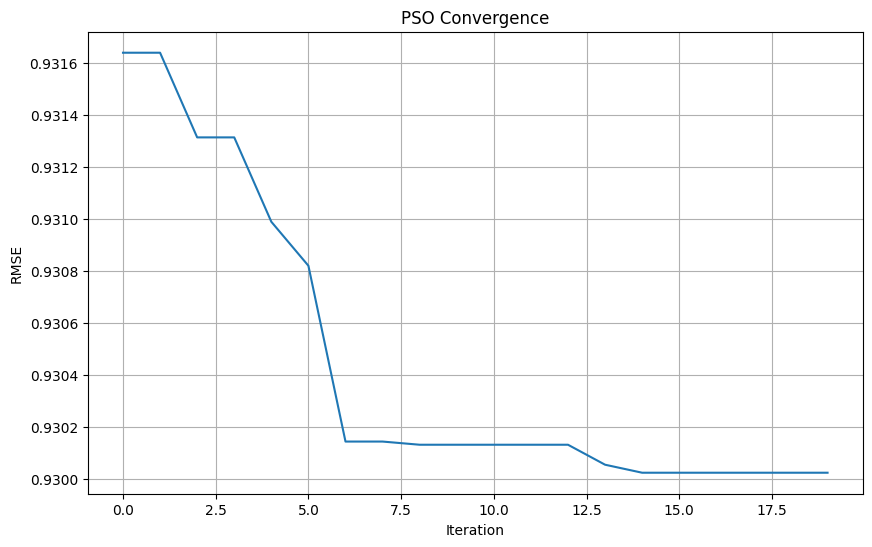

In [ ]:
# --------------------------------------------------
# PARTICLE SWARM OPTIMIZATION
# --------------------------------------------------
class PSO:
    def __init__(self, n_particles, n_dimensions, bounds, fixed_data):
        self.n_particles = n_particles
        self.n_dimensions = n_dimensions
        self.bounds = bounds  # [[min_d1, max_d1], [min_d2, max_d2], ...]
        self.fixed_data = fixed_data

        # Initialize particles and velocities
        self.particles = np.random.uniform(
            low=[b[0] for b in bounds],
            high=[b[1] for b in bounds],
            size=(n_particles, n_dimensions)
        )

        # Handle L1 + L2 <= 1 constraint
        for i in range(n_particles):
            while self.particles[i, 0] + self.particles[i, 1] > 1:
                self.particles[i, :2] = np.random.uniform(0, 0.5, size=2)

        # Initialize velocities
        velocity_bounds = [(b[1] - b[0]) * 0.1 for b in bounds]
        self.velocities = np.random.uniform(
            low=[-vb for vb in velocity_bounds],
            high=velocity_bounds,
            size=(n_particles, n_dimensions)
        )

        # Initialize best positions and scores
        self.pbest_positions = self.particles.copy()
        self.pbest_scores = np.array([self.evaluate(p) for p in self.particles])

        # Global best
        gbest_idx = np.argmin(self.pbest_scores)
        self.gbest_position = self.pbest_positions[gbest_idx].copy()
        self.gbest_score = self.pbest_scores[gbest_idx]

        # Parameters
        self.w = 0.8  # Inertia weight
        self.c1 = 1  # Cognitive coefficient
        self.c2 = 1.5  # Social coefficient

    def evaluate(self, params):
        """Evaluate a particle's position."""
        # Apply constraints
        if params[0] + params[1] > 1:
            return np.inf

        return evaluate_params(params, self.fixed_data)

    def update(self):
        """Update particle positions and velocities."""
        r1 = np.random.random(size=(self.n_particles, self.n_dimensions))
        r2 = np.random.random(size=(self.n_particles, self.n_dimensions))

        # Update velocities
        cognitive = self.c1 * r1 * (self.pbest_positions - self.particles)
        social = self.c2 * r2 * (self.gbest_position - self.particles)
        self.velocities = self.w * self.velocities + cognitive + social

        # Apply velocity constraints
        for d in range(self.n_dimensions):
            max_vel = 0.2 * (self.bounds[d][1] - self.bounds[d][0])
            self.velocities[:, d] = np.clip(self.velocities[:, d], -max_vel, max_vel)

        # Update positions
        self.particles += self.velocities

        # Apply boundary constraints
        for d in range(self.n_dimensions):
            self.particles[:, d] = np.clip(self.particles[:, d], self.bounds[d][0], self.bounds[d][1])

        # Handle L1 + L2 <= 1 constraint
        for i in range(self.n_particles):
            if self.particles[i, 0] + self.particles[i, 1] > 1:
                scale = 1 / (self.particles[i, 0] + self.particles[i, 1])
                self.particles[i, 0] *= scale * 0.99  # Scale slightly below 1 to avoid floating-point issues
                self.particles[i, 1] *= scale * 0.99

        # Update personal bests
        scores = np.array([self.evaluate(p) for p in self.particles])
        better_indices = scores < self.pbest_scores

        self.pbest_scores[better_indices] = scores[better_indices]
        self.pbest_positions[better_indices] = self.particles[better_indices].copy()

        # Update global best
        min_idx = np.argmin(self.pbest_scores)
        if self.pbest_scores[min_idx] < self.gbest_score:
            self.gbest_score = self.pbest_scores[min_idx]
            self.gbest_position = self.pbest_positions[min_idx].copy()

    def run(self, max_iter=30, early_stop=5):
        """Run PSO optimization."""
        print("Starting PSO optimization...")
        no_improve_count = 0
        best_score_history = [self.gbest_score]

        for iteration in range(max_iter):
            self.update()

            # Print progress
            print(f"Iteration {iteration+1}/{max_iter}, Best RMSE: {self.gbest_score:.4f}, "
                  f"Params: L1={self.gbest_position[0]:.2f}, L2={self.gbest_position[1]:.2f}, "
                  f"alpha={self.gbest_position[2]:.2f}")

            # Check for improvement
            if self.gbest_score < best_score_history[-1]:
                no_improve_count = 0
                best_score_history.append(self.gbest_score)
            else:
                no_improve_count += 1
                best_score_history.append(best_score_history[-1])

            # Early stopping
            if no_improve_count >= early_stop:
                print(f"Early stopping after {iteration+1} iterations with no improvement.")
                break

        return self.gbest_position, self.gbest_score, best_score_history


# Assuming these variables are defined from your existing code
# sim_age, sim_gender, sim_genre, hfm_sim, rating100k_df, rating100k, user_avg_ratings

# Create fixed data tuple for evaluation
user_avg_ratings_array = user_avg_ratings100k.sort_index().to_numpy()

# Precompute item_rated_users
item_rated_users = {}
for item_idx in range(rating100k.shape[1]):
    rated_users = np.where(rating100k[:, item_idx] != 0)[0]
    item_rated_users[item_idx] = rated_users

# Convert similarity matrices to NumPy if they aren't already
sim_age_np = sim_age100k.to_numpy() if hasattr(sim_age100k, 'to_numpy') else sim_age100k
sim_gender_np = sim_gender100k.to_numpy() if hasattr(sim_gender100k, 'to_numpy') else sim_gender100k
sim_genre_np = sim_genre100k.to_numpy() if hasattr(sim_genre100k, 'to_numpy') else sim_genre100k
hfm_sim_np = hfm_sim100k.to_numpy() if hasattr(hfm_sim100k, 'to_numpy') else hfm_sim100k

fixed_data = (
    sim_age_np,
    sim_gender_np,
    sim_genre_np,
    hfm_sim_np,
    rating100k_df,
    user_avg_ratings_array,
    rating100k,
    item_rated_users
)

# Define PSO parameters
n_particles = 20
n_dimensions = 3  # L1, L2, alpha
bounds = [
    [0.0, 1.0],  # L1 bounds
    [0.0, 1.0],  # L2 bounds
    [0.0, 1.0]   # alpha bounds
]

# Run PSO
start_time = time.time()
pso = PSO(n_particles, n_dimensions, bounds, fixed_data)
best_params, best_rmse, history = pso.run(max_iter=30, early_stop=5)

elapsed = time.time() - start_time
print(f"\nPSO Optimization completed in {elapsed:.2f} seconds")
print(f"Best RMSE: {best_rmse:.4f}")
print(f"Best Parameters: L1={best_params[0]:.4f}, L2={best_params[1]:.4f}, alpha={best_params[2]:.4f}")
print(f"L3 (derived): {1-best_params[0]-best_params[1]:.4f}")

# Verify with one final evaluation
L1, L2, alpha = best_params
final_rmse = evaluate_params(best_params, fixed_data)
print(f"Verification RMSE: {final_rmse:.4f}")

# Plot convergence history if matplotlib is available
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.plot(history)
    plt.title('PSO Convergence')
    plt.xlabel('Iteration')
    plt.ylabel('RMSE')
    plt.grid(True)
    plt.show()
except ImportError:
    print("Matplotlib not available for plotting convergence history")

# **DEALING WITH MOVIE COLD START**

In order to deal with movie cold strat we are going to use the movie dataframe to compute a similarity between various movies.

In this section we will adress the problem of movie cold start, which refers to the fact that a new movie in the dataset has a very low probability of being recommended to users.

To address this problem, we will consider movie descriptions, which will be referenced as "plots" from now on.

Similar movie plots can effectively alleviate the movie cold start problem while compensating for the hidden movie feature matrix caused by information loss.

The plots of the movies will be extracted from wikipedia using the wikipedia API.

## Extracting the plot from wikipedia

First of all, we need to use the wikipedia API to extract the plot of each movie.

Each search string has been added because of some examples that have been found in the dataset.

In [ ]:
def get_wikipedia_plot(title, lang='en'):
    wiki_wiki = wikipediaapi.Wikipedia(
        user_agent = "My NAML project",
        language=lang
    )

    search_strings = []

    # Remove the year of release from the title
    search = re.sub(r'\(\d{4}\)', '', title).strip()
    search_strings.append(search)

    # let's try to add back the year and add 'film' in the parethesis
    search = title[:-1]
    search = search + ' film)'
    search_strings.append(search)

    # let's try to remove the year and leave only 'film' in the parethesis
    search = re.sub(r'\(\d{4}\)', '', title).strip()
    search = search + ' (film)'
    search_strings.append(search)

    # let's try to remove everything in parethesis
    search = re.sub(r'\([^)]*\)', '', title).strip()
    search_strings.append(search)

    # let's try to remove everything in parethesis and add (release year film)
    search = re.sub(r'\([^)]*\)', '', title).strip()
    search = search + ' (' + title[-5:-1] + ' film)'
    search_strings.append(search)

    # let's try to remove everything in parenthesis and leave only 'film in parenthesis
    search = re.sub(r'\([^)]*\)', '', title).strip()
    search = search + ' (film)'
    search_strings.append(search)

    # sometimes, movies titles are like: 'White Balloon, The (1995)', we need to remove everything in parethesis and then put the part after the comma ',' before everything. The considered comma must be the last
    search = re.sub(r'\([^)]*\)', '', title).strip()
    parts = search.rsplit(',', 1)
    if len(parts) == 2:
        search = parts[1].strip() + ' ' + parts[0].strip()
        search_strings.append(search)

        # add (release year film)
        search = parts[1].strip() + ' ' + parts[0].strip() + ' (' + title[-5:-1] + ' film)'
        search_strings.append(search)

        # add (film)
        search = parts[1].strip() + ' ' + parts[0].strip() + ' (film)'
        search_strings.append(search)

    # Let's performs a search for every string we found
    for search in search_strings:
        page = wiki_wiki.page(search)

        # Let's get all the text, except for the sections "See also", "References", "External links", "Notes", "Bibliography"
        text = page.text

        for section in page.sections:
            if section.title in ["See also", "References", "External links", "Notes", "Bibliography"]:
                text = text.replace(section.text, "")
            text = text.replace(section.title, "")
            text = text.replace("\n\n", " ")
            text = text.replace("\n", " ")

        return text

    return None

Now it is useful to save all the plots in a dictionary, so to have easy access to them.

In [ ]:
plots = {}

for i in tqdm(range(1, len(film100k_df))):
    movie = film100k_df['title'][i]
    plot = get_wikipedia_plot(movie)
    if plot == None:
      continue
    else:
      plots[movie] = plot

print(f'Number of movies with plots: {len(plots)}')
print(f'Number of movies without plots: {len(film100k_df) - len(plots)}')
print(f'Total number of movies: {len(film100k_df)}')

  0%|          | 0/1681 [00:00<?, ?it/s]

Number of movies with plots: 1663
Number of movies without plots: 19
Total number of movies: 1682


Movies not in *plots* don't manage to find any result for two main reasons:

* The movie title in the dataset is wrong
* The movie title in the dataset has more or less uppercase letters than the one in wikipedia

This behaviours cannot be captured by a regex, so there is no way of finding the wikipedia page related to those movies.

Nonetheless, this can still be considered a good result.

Here is the plot of the first movie of the dataset:

In [ ]:
# let's print the plot of the first movie
movie = film100k_df['title'][1]
plot = plots[movie]
print(f'plot for movie {movie}:\n{plot}')

plot for movie Toy Story (1995):
Toy Story is a 1995 American animated adventure comedy film produced by Pixar Animation Studios for Walt Disney Pictures. It is the first installment in the Toy Story franchise and the first entirely computer-animated feature film, as well as the first feature film from Pixar. The film was directed by John Lasseter, written by Joss Whedon, Andrew Stanton, Joel Cohen, and Alec Sokolow based on a story by Lasseter, Stanton, Pete Docter, and Joe Ranft, produced by Bonnie Arnold and Ralph Guggenheim, and features the voices of Tom Hanks, Tim Allen, Annie Potts, John Ratzenberger, Don Rickles, Wallace Shawn, and Jim Varney. Taking place in a world where toys come to life when humans are not present, the plot of Toy Story focuses on the relationship between an old-fashioned pullstring cowboy doll named Woody and a modern space cadet action figure, Buzz Lightyear, as Woody develops jealousy towards Buzz when he becomes their owner Andy's favorite toy. Followin

## Computing the log-likelihood

The next step is to compute the feature extraction using log-likelihood based on the plot.

In [ ]:
# Download stopwords and punctuation from nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

def preprocess_corpus(corpus):
    stop_words = set(nltk.corpus.stopwords.words('english'))
    corpus_tokens = [
        word.lower()
        for text in corpus
        for word in nltk.word_tokenize(text)
        if word.isalpha() and word.lower() #not in stop_words
    ]
    corpus_counts = Counter(corpus_tokens)
    total_words = sum(corpus_counts.values())
    return corpus_counts, total_words

def compute_log_likelihood(plot, corpus_counts, corpus_total_words):
    stop_words = set(nltk.corpus.stopwords.words('english'))
    plot_tokens = [word.lower() for word in nltk.word_tokenize(plot) if word.isalpha() and word.lower()] #not in stop_words]
    plot_counts = Counter(plot_tokens)
    plot_total_words = sum(plot_counts.values())

    c = plot_total_words
    d = corpus_total_words

    ll_scores = {}

    for word in plot_counts:
        a = plot_counts[word]
        b = corpus_counts.get(word, 0)

        if a == 0 and b == 0:
            continue

        e1 = (a + b) * (c / (c + d))
        e2 = (a + b) * (d / (c + d))

        term1 = a * math.log(a / e1) if a > 0 else 0
        term2 = b * math.log(b / e2) if b > 0 else 0

        ll = 2 * (term1 + term2)
        ll_scores[word] = ll

    return ll_scores

corpus_counts, corpus_total_words = preprocess_corpus(plots.values())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Let's compute the log-likelihood dictionaries for a couple of movies.

In [ ]:
corpus_params = (corpus_counts, corpus_total_words)

# example with the first movie
movie = film100k_df['title'][1]
plot = plots[movie]
print(f'Considering movie {movie}')
print()
features = compute_log_likelihood(plot, corpus_counts, corpus_total_words)
print(f'features:\n{features}')

# select the top-5 influencial features
top_features = sorted(features.items(), key=lambda x: x[1], reverse=True)[:5]
print(f'\ntop-5 influencial features:\n{top_features}')


# do the same for "Apollo 13 (1995)"
movie = 'Apollo 13 (1995)'
plot = plots[movie]
print(f'\n\n\nConsidering movie {movie}')
print()
features = compute_log_likelihood(plot, corpus_counts, corpus_total_words)
print(f'features:\n{features}')
top_features = sorted(features.items(), key=lambda x: x[1], reverse=True)[:5]
print(f'\ntop-5 influencial features:\n{top_features}')

Considering movie Toy Story (1995)

features:
{'toy': 1011.9736556771275, 'story': 312.1190653296359, 'is': 40.065194062521414, 'a': 0.03276137229580378, 'american': 6.519564154286709, 'animated': 68.69508567335484, 'adventure': 1.5462402208550956, 'comedy': 3.1381515001243504e-05, 'film': 66.6722621996008, 'produced': 1.2962560727680899, 'by': 13.287293831026787, 'pixar': 425.20395799561203, 'animation': 179.28731572988562, 'studios': 3.743531801101824, 'for': 7.947097802955071, 'walt': 27.222408291854563, 'disney': 305.09446784776213, 'pictures': 0.4663244984527086, 'it': 2.7113802945620833, 'the': 0.8358527220146073, 'first': 30.094857441671145, 'installment': 0.8306708535437393, 'in': 9.807501327225395, 'franchise': 0.4494187452644245, 'and': 0.0003063631536902589, 'entirely': 0.1836584818595367, 'feature': 44.540100652083574, 'as': 3.9168068659965414, 'well': 8.778011463715725, 'from': 1.7472230667983233, 'was': 19.357334681318875, 'directed': 2.3739386311574298, 'john': 4.1557311

We can see that our implementation is working well.

We notice that the most influencial features of *Toy Story* are words like *toy*, *pixar* or *buzz*, which are extremely important when describing this movie.

The same can be said about *Apollo 13*, where words like *apollo*, *nasa* and *moon* are for sure among the most important.

## Computing the CBOW representation of the plots

The next step is to emply the Continous Bag of Words (CBOW) model in Word2Vec.

First we need to build the model through our plots dictionary:

In [ ]:
# Extract only the plots and put them in a list
plots_for_embedding = list(plots.values())

# Remove the plot if it is empty
plots_for_embedding = [p for p in plots_for_embedding if len(p.strip()) > 0]

# Tokenize the plots and filter-out the stopwords
tokenized_plots = [nltk.word_tokenize(plot.lower()) for plot in plots_for_embedding]
stop_words = set(nltk.corpus.stopwords.words('english'))
filtered_plots = [[w for w in plot if not w in stop_words and w.isalnum()] for plot in tokenized_plots]

# Create the Word2Vec model
embedding_model = Word2Vec(filtered_plots, min_count=1, vector_size=300, window=10, workers=4, sg=0)

# Save the words' embeddings
embeddings = embedding_model.wv

In [ ]:
def compute_cbow_embeddings(plot, embeddings):
    if plot is None or len(plot) == 0:
        # Return an empty dictionary for missing plots
        return None

    # Tokenize the plot and filter-out stopwords
    tokens = nltk.word_tokenize(plot.lower())
    stop_words = set(nltk.corpus.stopwords.words('english'))
    filtered_tokens = [w for w in tokens if not w in stop_words and w.isalnum()]

    # Create a dictionary to store word embeddings
    word_embeddings = {}
    for word in filtered_tokens:
        try:
            word_embeddings[word] = embeddings[word]
        except KeyError:
            # Handle words not in vocabulary (could be rare words)
            continue

    return word_embeddings


In [ ]:
# example on the first movie
movie = film100k_df['title'][1]
plot = plots[movie]
movie_embedding = compute_cbow_embeddings(plot, embeddings)

print(f'plot for movie {movie}:\n{plot}')
print(f'\n\nembedding:\n{movie_embedding}')

Output streaming troncato alle ultime 5000 righe.
        6.49852529e-02,  5.48076406e-02, -4.81643945e-01,  2.84445226e-01,
        5.29047191e-01,  3.09891760e-01,  4.41419221e-02, -7.64366463e-02,
        2.44333133e-01,  4.13116455e-01,  5.06830752e-01,  2.24002108e-01,
       -2.23315835e-01, -3.03807050e-01,  7.77306333e-02, -1.48745060e-01],
      dtype=float32), 'steez': array([ 2.14904617e-03,  1.40078380e-04, -2.82539893e-03,  5.01070544e-03,
        4.68663452e-03, -8.00098293e-03, -5.94579522e-03, -2.99128029e-03,
       -1.07560251e-02,  1.85193075e-03, -1.44877275e-02, -7.22195860e-03,
        4.55300137e-03,  2.01816205e-02,  1.57222468e-02, -6.38717553e-03,
       -9.50376596e-03,  1.46802037e-03, -3.26253194e-03, -7.40535231e-03,
       -1.61386828e-03, -1.84790406e-04,  3.87463113e-03,  9.85248573e-03,
       -1.68059748e-02,  1.90467257e-02,  2.69860425e-03,  1.00412499e-02,
       -5.99260861e-03,  1.67626031e-02,  8.24767724e-03,  1.62439309e-02,
       -5.69151621

## Computing the movie vector

Now that we have the LL (Log-Likelihood) and the CBOW representation, we can compute the vector for every movie following this formula:

$$V_{movie} = \frac{\sum_{g = 1}^n LL_{(a_g)} V_{Word2Vec(a_g)}}{\sum_{g = 1}^n LL_{(a_g)}}$$

* $V_{movie}$: the final movie vector
* $LL_{a_g}$: the log-likelihood of the word
* $V_{Word2Vec(a_g)}$: the CBOW representation of the word

In [ ]:
def compute_movie_vector(title, plots, embeddings, corpus_params):
  if title not in plots:
    # There is no plot for this movie, so we cannot compute its vector
    return None

  # Extract the wanted plot
  plot = plots[title]

  # Compute the log-likelihood of the words in the plot
  ll_features = compute_log_likelihood(plot, corpus_params[0], corpus_params[1])

  # Compute the CBOW embedding of the words in the plot
  cbow_embeddings = compute_cbow_embeddings(plot, embeddings)

  # If they are not computed return None
  if ll_features is None or cbow_embeddings is None:
    return None

  # Inizialize the movie vector
  movie_vec = np.zeros(300)

  ll_to_consider = []

  # Compute the numerator
  for word, ll in ll_features.items():
    if word in cbow_embeddings:
      movie_vec += ll * cbow_embeddings[word]
      ll_to_consider.append(ll)

  # Compute the denominator
  ll_sum = sum(ll_to_consider)

  if ll_sum > 0:
    movie_vec /= ll_sum

  return movie_vec

Now we can compute and store all the movie vectors, so that we will have easy access to them in the creation of the predicted ratings.

In [ ]:
movie_vectors = {}

for i in tqdm(range(1, len(film100k_df))):
  movie = film100k_df['title'][i]
  movie_vec = compute_movie_vector(movie, plots, embeddings, corpus_params)
  if movie_vec is not None:
    movie_vectors[movie] = movie_vec

  0%|          | 0/1681 [00:00<?, ?it/s]

## Computing the similarity for different movie vectors

Now we can define the RV coefficient, to measure the similarity between movie vectors:

$$RV_{a, b} = \frac{\sum_{g=1}^s (a_g \cdot b_g)}{\sqrt{\sum_{g=1}^n(a_g)^2}*\sqrt{\sum_{g=1}^m(b_g)^2}}$$

* $RV_{a, b}$: the RV coefficient which measures the similarity between vector a and vector b
* $a_g$: g-th element of vector $a$
* $b_g$: g.th element of vector $b$

In [ ]:
def rv_coefficient(movie_vec_a, movie_vec_b):
    if movie_vec_a is None or movie_vec_b is None:
        # Handle cases where movie vectors are not available
        return 0

    # Compute the numerator
    dot_product = np.dot(movie_vec_a, movie_vec_b)

    # Compute the denominator
    magnitude_a = np.sqrt(np.sum(movie_vec_a ** 2))
    magnitude_b = np.sqrt(np.sum(movie_vec_b ** 2))

    # If the denominator is 0, return 0
    if magnitude_a == 0 or magnitude_b == 0:
        return 0

    return dot_product / (magnitude_a * magnitude_b)


## Weight the result with the hidden movie feature matrix

We compute the overall similarity of two movies combining the just obtained vector representation, with the relative hidden movie feature matrix. In order to achieve so, we exploit this formula:

$$Sim_{(i,j)} = \alpha_mSim_{(i,j)}HFM_m + \beta_mRV_{(i.j)}$$

Where $Sim_{(i,j)}HFM_m$ denotes the cosine similarity between movies $i$ and $j$ in the hidden movie feature vector matrix.

The best parameters that have been found are $\alpha=0.3$ and $\beta=0.7$.

In [ ]:
def overall_movie_similarity(movie1, movie2, film_df, item_hidden, plots, embeddings, movie_vectors, alpha = 0.3, beta = 0.7):
    # Extract the index of the two movies in the dataset
    idx1 = film_df[film_df['title'] == movie1].index[0]
    idx2 = film_df[film_df['title'] == movie2].index[0]

    # Extract the ALS movie hidden vector of the two movies
    ALS_1 = item_hidden[idx1]
    ALS_2 = item_hidden[idx2]

    # Extract the movie vectors
    v_1 = movie_vectors[movie1]
    v_2 = movie_vectors[movie2]

    # Calculate cosine similarity using ALS movie vectors
    sim_als = cosine_similarity(ALS_2.reshape(1, -1), ALS_1.reshape(1, -1))[0][0]

    # Calculate RV coefficient
    sim_rv = rv_coefficient(v_2, v_1)

    # Calculate overall similarity
    overall_sim = (alpha * sim_als) + (beta * sim_rv)

    return overall_sim


Let's try to compute the most and least similar movie with *Toy Story*:

In [ ]:
# compute the similarity between Toy Story and it's least similar movie
movie_1 = 'Toy Story (1995)'

# find the least similar movie
least_sim_score = np.float64('inf')
least_sim_movie = ''
for i in range(1, len(film100k_df)):
  movie = film100k_df['title'][i]
  if movie != movie_1 and movie in movie_vectors:
    sim = overall_movie_similarity(movie_1, movie, film100k_df, item_hidden_100k, plots, embeddings, movie_vectors)
    if sim < least_sim_score:
      least_sim_score = sim
      least_sim_movie = movie

print(f'The least similar movie to {movie_1} is {least_sim_movie} with a similarity of {least_sim_score}')

The least similar movie to Toy Story (1995) is Baton Rouge (1988) with a similarity of 0.28275726108337396


In [ ]:
# compute the similarity between Toy Story and it's most similar movie
movie_1 = 'Toy Story (1995)'

# find the most similar movie
most_sim_score = np.float64('-inf')
most_sim_movie = ''
for i in range(1, len(film100k_df)):
  movie = film100k_df['title'][i]
  if movie != movie_1 and movie in movie_vectors:
    sim = overall_movie_similarity(movie_1, movie, film100k_df, item_hidden_100k, plots, embeddings, movie_vectors)
    if sim > most_sim_score:
      most_sim_score = sim
      most_sim_movie = movie

print(f'The most similar movie to {movie_1} is {most_sim_movie} with a similarity of {most_sim_score}')

The most similar movie to Toy Story (1995) is Lion King, The (1994) with a similarity of 0.9536944813173696


Let's consider the most similar and most dissimilar movies to *Toy Story*:
* the least similar is *Baton Rouge (1988)*. It is a 1988 Spanish neo-noir thriller film which talks about a wealthy woman, Isabel Harris, who is blackmailed by cold psychiatrist Ana Alonso and the gold-digging gigolo Antonio, who team up to frame Isabel in a crime. We can notice it being pretty different from *Toy Story*!
* the most similar movie is *The lion King (1994)*. It is a 1994 american animation movie that talks about a young lion prince, Simba, flees his kingdom after his father is killed by his uncle. Years later, Simba returns to reclaim his rightful place as king. It is a kids' movie, just like *Toy Story*.

Now we can compute the similarity matrix. Here there will be stored all the similarities between each pair of movie.

In [ ]:
def compute_similarity_matrix(movie_vectors, film_df, item_hidden, plots, embeddings, alpha = 0.7, beta = 0.3):
    n_movies = len(film_df)
    similarity_matrix = np.zeros((n_movies, n_movies))
    cosine_sim_matrix = np.zeros((n_movies, n_movies))
    rv_sim_matrix = np.zeros((n_movies, n_movies))

    for i in tqdm(range(1, n_movies)):
        cos_sim_batch = []
        indices = []

        for j in range(i + 1, n_movies):
            try:
                # Try to access movie titles using the index
                movie1 = film_df['title'][i + 1]  # Adding 1 because movie IDs start from 1
                movie2 = film_df['title'][j + 1]  # Adding 1 because movie IDs start from 1
            except KeyError:
                # If KeyError, skip this pair of movies
                continue

            if movie1 in movie_vectors and movie2 in movie_vectors:
                ALS2 = item_hidden[j]
                cos_sim_batch.append(ALS2)
                indices.append(j)
                # cosine_sim_matrix[i, j] = cosine_similarity(movie_vectors[movie1].reshape(1, -1), movie_vectors[movie2].reshape(1, -1))[0][0]
                rv_sim_matrix[i, j] = rv_coefficient(movie_vectors[movie1], movie_vectors[movie2])

        if cos_sim_batch:
          cos_sim_batch = np.stack(cos_sim_batch)  # shape: (num_comparisons, vector_dim)
          ALS1 = item_hidden[i]
          sim_scores = cosine_similarity(cos_sim_batch, ALS1.reshape(1, -1)).flatten()
          for k, j in enumerate(indices):
              cosine_sim_matrix[i - 1, j - 1] = sim_scores[k]

    similarity_matrix = (alpha * cosine_sim_matrix) + (beta * rv_sim_matrix)
    # make it symmetric
    similarity_matrix = (similarity_matrix + similarity_matrix.T) / 2
    np.fill_diagonal(similarity_matrix, 1)

    return similarity_matrix


## Create the rating prediction

The last step is to create the rating matrix from what we obtained in this section. In order to achieve this, we will use TOP-N and the following formula:

$$\hat{R}_{a,i} = \overline{R}_i+\frac{\sum_{j\in Top-n}^n Sim_{i,j}(R_j-\overline{R}_j)}{\sum_{j\in Top-n}^n Sim_{i,j}}$$

Where:

* $\hat{R}_{a,i}​$ is the predicted rating for user $a$ on movie $i$.
* $\overline{R}_i$ is the average rating of movie $i$
* The sum in the numerator represents a weighted aggregation of rating deviations for the Top-N most similar movies.
* The denominator ensures normalization by dividing by the total similarity score.

First, we define a function precompute all the movies' averages.

In [ ]:
def precompute_average_ratings(rating_matrix):
  avg_movie_ratings = {}
  num_users, num_items = rating_matrix.shape

  for item_idx in range(num_items):
    avg_rating = np.mean(rating_matrix[:, item_idx])
    avg_movie_ratings[item_idx] = avg_rating

  return avg_movie_ratings

Now we can compute the full matrix for the predictions.

In [ ]:
def compute_full_rating_matrix_movie_cold_start(rating_matrix, film_df, movie_vectors, item_hidden, plots, embeddings,  alpha = 0.7, beta = 0.3, similarity_matrix = None):
    # compute the similarity matrix
    if similarity_matrix is None:
      print("Computing similarity matrix...")
      similarity_matrix = compute_similarity_matrix(movie_vectors, film_df, item_hidden, plots, embeddings, alpha, beta)
      print("Similarity matrix computed.")

    num_users, num_movies = rating_matrix.shape

    # Precompute item_rated_users
    item_rated_users = {}
    for i in range(num_movies):
        item_rated_users[i] = np.where(rating_matrix[:, i] > 0)[0]

    # compute average movie ratings
    avg_movie_ratings = precompute_average_ratings(rating_matrix)
    print("Average movie ratings computed.")

    # Initialize prediction matrix
    prediction_matrix = np.zeros((num_users, num_movies))

    # Fill in the matrix with movie average ratings as default
    for i in range(num_movies):
        prediction_matrix[:, i] = avg_movie_ratings[i]

    not_enough_top_n_couples_5 = []
    not_enough_top_n_couples_3 = []
    not_enough_top_n_couples_1 = []
    not_enough_top_n_couples_10 = []
    not_enough_5_mask = np.ones_like(rating_matrix)
    not_enough_3_mask = np.ones_like(rating_matrix)
    not_enough_1_mask = np.ones_like(rating_matrix)
    not_enough_10_mask = np.zeros_like(rating_matrix)
    # Compute predictions
    print("Computing predictions...")
    for item_idx in tqdm(range(num_movies)):
        try:

            if item_idx < similarity_matrix.shape[0]:
                # Extract the row of similarity matrix corresponding to item_idx
                item_similarities = similarity_matrix[item_idx]
            else:
                prediction_matrix[:, item_idx] = 0
                continue

            # Sort the similarities in descending order
            sorted_indices = np.argsort(item_similarities)[::-1][:20]

            for user_idx in range(num_users):
                  if rating_matrix[user_idx, item_idx] > 0:
                    continue

                  # Get all the movies rated by user_idx
                  user_rated_movies = np.where(rating_matrix[user_idx] > 0)

                  # intersect the movies rated by user_idx and the top movies similar to item_idx to obtain top-10
                  top_n, _, similarity_idx = np.intersect1d(user_rated_movies, sorted_indices, return_indices=True)
                  top_n = top_n[np.argsort(similarity_idx)][:10]

                  if len(top_n) == 0:
                    prediction_matrix[user_idx, item_idx] = avg_movie_ratings[item_idx]
                    continue

                  if len(top_n) <= 5:
                    #print(f'for movie {film_df["title"][item_idx + 1]} and user {user_idx + 1} the top-n size is {len(top_n)}')
                    not_enough_top_n_couples_5.append((user_idx, film_df["title"][item_idx + 1]))
                    not_enough_5_mask[user_idx, item_idx] = 0

                    if len(top_n) <= 3:
                      not_enough_top_n_couples_3.append((user_idx, film_df["title"][item_idx + 1]))
                      not_enough_3_mask[user_idx, item_idx] = 0

                      if len(top_n) <= 1:
                        not_enough_top_n_couples_1.append((user_idx, film_df["title"][item_idx + 1]))
                        not_enough_1_mask[user_idx, item_idx] = 0

                      prediction_matrix[user_idx, item_idx] = avg_movie_ratings[item_idx]
                      continue

                  if len(top_n) == 10:
                    not_enough_top_n_couples_10.append((user_idx, film_df["title"][item_idx + 1]))
                    not_enough_10_mask[user_idx, item_idx] = 1


                  # Compute the prediction
                  numerator = 0
                  denominator = 0
                  for movie_id in top_n:
                    numerator += similarity_matrix[item_idx, movie_id] * (rating_matrix[user_idx, movie_id] - avg_movie_ratings[movie_id])
                    denominator += similarity_matrix[item_idx, movie_id]

                  if denominator != 0:
                    prediction_matrix[user_idx, item_idx] = avg_movie_ratings[item_idx] + (numerator / denominator)
        except KeyError:
            continue

    print("Predictions computed.")
    return prediction_matrix, not_enough_top_n_couples_5, not_enough_top_n_couples_3, not_enough_top_n_couples_1, not_enough_top_n_couples_10, not_enough_5_mask, not_enough_3_mask, not_enough_1_mask, not_enough_10_mask

## Compute the rating matrix

Now we can compute the prediction matrix for the 100k dataset.

In [ ]:
plots100k = plots

movie_vectors100k = movie_vectors

embeddings_100k = embeddings

In [ ]:
similarity_matrix = compute_similarity_matrix(movie_vectors100k, film100k_df, item_hidden_100k, plots100k, embeddings_100k)

  0%|          | 0/1681 [00:00<?, ?it/s]

In [ ]:
# train the new rating_train
prediction_matrix_train, not_enough_5, not_enough_3, not_enough_1, not_enough_10, less_5_mask, less_3_mask, less_1_mask, less_10_mask = compute_full_rating_matrix_movie_cold_start(train100k_matrix, film100k_df, movie_vectors100k, item_hidden_100k, plots100k, embeddings_100k, similarity_matrix=similarity_matrix)
prediction_matrix_train = np.clip(prediction_matrix_train, 1, 5)

Average movie ratings computed.
Computing predictions...


  0%|          | 0/1682 [00:00<?, ?it/s]

Predictions computed.


Now let's take a look at the number elements in the top-n for the pairs movie-user.

In [ ]:
5print("___________________________________________________________________________________________________________________________________________________________\n")
print(f"The number of insufficient top-n pairs between users and items is: {len(not_enough_5)} (considering insufficient a top-n size <=5)\n")
print(f"The total number of item-user pairs are: {prediction_matrix_train.shape[0] * prediction_matrix_train.shape[1]}")
print(f"It corresponds to {math.ceil((len(not_enough_5) * 100) / (prediction_matrix_train.shape[0] * prediction_matrix_train.shape[1]))}% of the total pairs\n")

print("___________________________________________________________________________________________________________________________________________________________\n")
print(f"The number of insufficient top-n pairs between users and items is: {len(not_enough_3)} (considering insufficient a top-n size <=3)\n")
print(f"The total number of item-user pairs are: {prediction_matrix_train.shape[0] * prediction_matrix_train.shape[1]}")
print(f"It corresponds to {math.ceil((len(not_enough_3) * 100) / (prediction_matrix_train.shape[0] * prediction_matrix_train.shape[1]))}% of the total pairs\n")

print("___________________________________________________________________________________________________________________________________________________________\n")
print(f"The number of insufficient top-n pairs between users and items is: {len(not_enough_1)} (considering insufficient a top-n size <=1)\n")
print(f"The total number of item-user pairs are: {prediction_matrix_train.shape[0] * prediction_matrix_train.shape[1]}")
print(f"It corresponds to {math.ceil((len(not_enough_1) * 100) / (prediction_matrix_train.shape[0] * prediction_matrix_train.shape[1]))}% of the total pairs\n")

print("___________________________________________________________________________________________________________________________________________________________\n")
print(f"The number of sufficient top-n pairs between users and items is: {len(not_enough_10)} (considering sufficient a top-n size = 10)\n")
print(f"The total number of item-user pairs are: {prediction_matrix_train.shape[0] * prediction_matrix_train.shape[1]}")
print(f"It corresponds to {math.ceil((len(not_enough_10) * 100) / (prediction_matrix_train.shape[0] * prediction_matrix_train.shape[1]))}% of the total pairs\n")

___________________________________________________________________________________________________________________________________________________________

The number of insufficient top-n pairs between users and items is: 684505 (considering insufficient a top-n size <=5)

The total number of item-user pairs are: 1586126
It corresponds to 44% of the total pairs

___________________________________________________________________________________________________________________________________________________________

The number of insufficient top-n pairs between users and items is: 598147 (considering insufficient a top-n size <=3)

The total number of item-user pairs are: 1586126
It corresponds to 38% of the total pairs

___________________________________________________________________________________________________________________________________________________________

The number of insufficient top-n pairs between users and items is: 343777 (considering insufficient a top-n s

It seems like we don't have enough data to correctly predict all the ratings. Let's explain better the TOP-N of the user-movie pairs.

The TOP-N for a given movie pair is such computed:

```
for each movie
  find the 20 movies most similar to it
  # only 20 because then, we would consider also movies not similar to the said movie, and that's not what we want

  for each user
    find all the movies it has rated

    intersecate the most similar movies with the items the user has rated and consider only 10 of them
    # this is the TOP-N, which mantains the ordering from most to least similar
```

This means that for many movie-user couples we do not manage to find enough evidence to confidently predict all the rating matrix.

Let's try to compute the various RMSEs considering only a subset of the test set.

In [ ]:
test_mask = (test100k_matrix != 0).astype(int)
test_mask_np = np.where(test_mask == 1)

print("___________________________________________________________________________________________________________________________________________________________\n")
# compute the RMSE only on the data which is not in the mask less_5
mask_merged = np.logical_and(less_5_mask, test_mask)

rmse_res = compute_rmse(prediction_matrix_train[mask_merged], test100k_matrix[mask_merged])
print("Using only the couples with 5 or more elements in the top-n list.")
print(f"RMSE for train set: {rmse_res}\n")

print("___________________________________________________________________________________________________________________________________________________________\n")
# compute the RMSE only on the data which is not in the mask less_3
mask_merged = np.logical_and(less_3_mask, test_mask)

rmse_res = compute_rmse(prediction_matrix_train[mask_merged], test100k_matrix[mask_merged])
print("Using only the couples with 3 or more elements in the top-n list.")
print(f"RMSE for train set: {rmse_res}\n")

print("___________________________________________________________________________________________________________________________________________________________\n")
# compute the RMSE only on the data which is not in the mask less_1
mask_merged = np.logical_and(less_1_mask, test_mask)

rmse_res = compute_rmse(prediction_matrix_train[mask_merged], test100k_matrix[mask_merged])
print("Using only the couples with 1 or more elements in the top-n list.")
print(f"RMSE for train set: {rmse_res}\n")

print("___________________________________________________________________________________________________________________________________________________________\n")
# compute the RMSE only on the data which is in the mask less_10
mask_merged = np.logical_and(less_10_mask, test_mask)

rmse_res = compute_rmse(prediction_matrix_train[mask_merged], test100k_matrix[mask_merged])
print("Using only the couples with 10 elements in the top-n list.")
print(f"RMSE for train set: {rmse_res}\n")

print("___________________________________________________________________________________________________________________________________________________________\n")
rmse_res = compute_rmse(prediction_matrix_train[test_mask_np], test100k_matrix[test_mask_np])
print('Using all the couples')
print(f"RMSE for train set: {rmse_res}\n")

___________________________________________________________________________________________________________________________________________________________

Using only the couples with 5 or more elements in the top-n list.
RMSE for train set: 2.556161147225157

___________________________________________________________________________________________________________________________________________________________

Using only the couples with 3 or more elements in the top-n list.
RMSE for train set: 2.4130591061806026

___________________________________________________________________________________________________________________________________________________________

Using only the couples with 1 or more elements in the top-n list.
RMSE for train set: 2.471158542336692

___________________________________________________________________________________________________________________________________________________________

Using only the couples with 10 elements in the top-n lis

As we can see, our predictions were correct: we do not have enough evidence to correctly predict all the rating matrix. We can state this by looking at the fact that by considering only the movie-item pairs that have 10 elements in their TOP-N list, we obtain a reasonable RMSE.

In [ ]:
R3_100k = prediction_matrix_train
R3_correct_mask = np.logical_and(less_10_mask, test_mask)

We pass on our prediction matrix and the mask which tells us which item-user pairs are correctly computed.

Now we can do the same for the 1m dataset. But first we need to define:
* plots1m
* movie_vectors_1m
* embeddings_1m

**(ATTENTION)**

This code can take a lot of time to execute, so it was commented out. If you want to execute it, just remove the comments. Estimated execution time is left in the top comment of each cell

We need to divide the extraction of the plots in 2 separate loops because otherwise, the wikipedia API will negate access due to an overload of requests.

In [ ]:
# # exec. time: 1 min
# plots1m = {}

# for i in tqdm(range(1, len(film1m_df)//2)):
#     if len(film1m_df[film1m_df.index == i].index) == 0:
#        continue

#     # Extract the movie title
#     movie = film1m_df['title'][i]

#     # If the plot was already found, do not look it up on Wikipedia again
#     if movie in plots100k.keys():
#       plots1m[movie] = plots100k[movie]
#     else:
#       plot = get_wikipedia_plot(movie)
#       if plot == None:
#         continue
#       else:
#         plots1m[movie] = plot

  0%|          | 0/1940 [00:00<?, ?it/s]

In [ ]:
# # exec. time: 7 min
# for i in tqdm(range(len(film1m_df)//2, len(film1m_df))):
#     if len(film1m_df[film1m_df.index == i].index) == 0:
#        continue

#     # Extract the movie title
#     movie = film1m_df['title'][i]

#     # If the plot was already found, do not look it up on Wikipedia again
#     if movie in plots100k.keys():
#       plots1m[movie] = plots100k[movie]
#     else:
#       plot = get_wikipedia_plot(movie)
#       if plot == None:
#         continue
#       else:
#         plots1m[movie] = plot

# print(f'Number of movies with plots: {len(plots1m)}')
# print(f'Number of movies without plots: {len(film1m_df) - len(plots1m)}')
# print(f'Total number of movies: {len(film1m_df)}')

  0%|          | 0/1942 [00:00<?, ?it/s]

Number of movies with plots: 3813
Number of movies without plots: 70
Total number of movies: 3883


Now we need to create the CBOW model using all the plots found.

In [ ]:
# # exec. time: 2 min
# # Extract only the plots and put them in a list
# plots_for_embedding = list(plots1m.values())

# # Remove the plot if it is empty
# plots_for_embedding = [p for p in plots_for_embedding if len(p.strip()) > 0]

# # Tokenize the plots and filter-out the stopwords
# tokenized_plots = [nltk.word_tokenize(plot.lower()) for plot in plots_for_embedding]
# stop_words = set(nltk.corpus.stopwords.words('english'))
# filtered_plots = [[w for w in plot if not w in stop_words and w.isalnum()] for plot in tokenized_plots]

# # Create the Word2Vec model
# embedding_model = Word2Vec(filtered_plots, min_count=1, vector_size=300, window=10, workers=4, sg=0)

# # Save the words' embeddings
# embeddings1m = embedding_model.wv

Finally, we can compute all the movie vectors as explained previously.

In [ ]:
# # exec. time: 3 min
# corpus_params = preprocess_corpus(plots1m.values())
# movie_vectors1m = {}

# for i in tqdm(range(1, len(film1m_df))):
#   # Some indexes do not contain any data, so we can skip them
#   if len(film1m_df[film1m_df.index == i].index) == 0:
#        continue
#   # Extract the movie title
#   movie = film1m_df['title'][i]

#   # Compute the movie vector
#   movie_vec = compute_movie_vector(movie, plots1m, embeddings1m, corpus_params)
#   if movie_vec is not None:
#     movie_vectors1m[movie] = movie_vec

  0%|          | 0/3882 [00:00<?, ?it/s]

Now we can finally compute the rating matrix.

In [ ]:
# # exec. time: 40 min
# # compute the similarity matrix
# similarity_matrix = compute_similarity_matrix(movie_vectors1m, film1m_df, item_hidden_1m, plots1m, embeddings1m)

# # compute the prediction matrix
# prediction_matrix_train_1m, not_enough_5_1m, not_enough_3_1m, not_enough__1m3,not_enough_10_1m, less_5_mask_1m, less_3_mask_1m, less_1_mask_1m, less_10_mask_1m = compute_full_rating_matrix_movie_cold_start(train1m_matrix, film1m_df, movie_vectors1m, item_hidden_1m, plots1m, embeddings1m, similarity_matrix=similarity_matrix)

  0%|          | 0/3882 [00:00<?, ?it/s]

Average movie ratings computed.
Computing predictions...


  0%|          | 0/3952 [00:00<?, ?it/s]

Predictions computed.


In [ ]:
# print("___________________________________________________________________________________________________________________________________________________________\n")
# print(f"The number of insufficient top-n pairs between users and items is: {len(not_enough_5_1m)} (considering insufficient a top-n size <=5)\n")
# print(f"The total number of item-user pairs are: {prediction_matrix_train_1m.shape[0] * prediction_matrix_train_1m.shape[1]}")
# print(f"It corresponds to {math.ceil((len(not_enough_5_1m) * 100) / (prediction_matrix_train_1m.shape[0] * prediction_matrix_train_1m.shape[1]))}% of the total pairs\n")

# print("___________________________________________________________________________________________________________________________________________________________\n")
# print(f"The number of insufficient top-n pairs between users and items is: {len(not_enough_3_1m)} (considering insufficient a top-n size <=3)\n")
# print(f"The total number of item-user pairs are: {prediction_matrix_train_1m.shape[0] * prediction_matrix_train_1m.shape[1]}")
# print(f"It corresponds to {math.ceil((len(not_enough_3_1m) * 100) / (prediction_matrix_train_1m.shape[0] * prediction_matrix_train_1m.shape[1]))}% of the total pairs\n")

# print("___________________________________________________________________________________________________________________________________________________________\n")
# print(f"The number of insufficient top-n pairs between users and items is: {len(not_enough__1m3)} (considering insufficient a top-n size <=1)\n")
# print(f"The total number of item-user pairs are: {prediction_matrix_train_1m.shape[0] * prediction_matrix_train_1m.shape[1]}")
# print(f"It corresponds to {math.ceil((len(not_enough__1m3) * 100) / (prediction_matrix_train_1m.shape[0] * prediction_matrix_train_1m.shape[1]))}% of the total pairs\n")

# print("___________________________________________________________________________________________________________________________________________________________\n")
# print(f"The number of sufficient top-n pairs between users and items is: {len(not_enough_10_1m)} (considering sufficient a top-n size = 10)\n")
# print(f"The total number of item-user pairs are: {prediction_matrix_train_1m.shape[0] * prediction_matrix_train_1m.shape[1]}")
# print(f"It corresponds to {math.ceil((len(not_enough_10_1m) * 100) / (prediction_matrix_train_1m.shape[0] * prediction_matrix_train_1m.shape[1]))}% of the total pairs\n")

___________________________________________________________________________________________________________________________________________________________

The number of insufficient top-n pairs between users and items is: 8690163 (considering insufficient a top-n size <=5)

The total number of item-user pairs are: 23870080
It corresponds to 37% of the total pairs

___________________________________________________________________________________________________________________________________________________________

The number of insufficient top-n pairs between users and items is: 7824647 (considering insufficient a top-n size <=3)

The total number of item-user pairs are: 23870080
It corresponds to 33% of the total pairs

___________________________________________________________________________________________________________________________________________________________

The number of insufficient top-n pairs between users and items is: 4793328 (considering insufficient a to

In [ ]:
# test_mask = (test1m_matrix != 0).astype(int)
# test_mask_np = np.where(test_mask == 1)

# print("___________________________________________________________________________________________________________________________________________________________\n")
# # compute the RMSE only on the data which is not in the mask less_5
# mask_merged = np.logical_and(less_5_mask_1m, test_mask)

# rmse_res = compute_rmse(prediction_matrix_train_1m[mask_merged], test1m_matrix[mask_merged])
# print("Using only the couples with 5 or more elements in the top-n list.")
# print(f"RMSE for train set: {rmse_res}\n")

# print("___________________________________________________________________________________________________________________________________________________________\n")
# # compute the RMSE only on the data which is not in the mask less_3
# mask_merged = np.logical_and(less_3_mask_1m, test_mask)

# rmse_res = compute_rmse(prediction_matrix_train_1m[mask_merged], test1m_matrix[mask_merged])
# print("Using only the couples with 3 or more elements in the top-n list.")
# print(f"RMSE for train set: {rmse_res}\n")

# print("___________________________________________________________________________________________________________________________________________________________\n")
# # compute the RMSE only on the data which is not in the mask less_1
# mask_merged = np.logical_and(less_1_mask_1m, test_mask)

# rmse_res = compute_rmse(prediction_matrix_train_1m[mask_merged], test1m_matrix[mask_merged])
# print("Using only the couples with 1 or more elements in the top-n list.")
# print(f"RMSE for train set: {rmse_res}\n")

# print("___________________________________________________________________________________________________________________________________________________________\n")
# # compute the RMSE only on the data which is in the mask less_10
# mask_merged = np.logical_and(less_10_mask_1m, test_mask)

# rmse_res = compute_rmse(prediction_matrix_train_1m[mask_merged], test1m_matrix[mask_merged])
# print("Using only the couples with 10 elements in the top-n list.")
# print(f"RMSE for train set: {rmse_res}\n")

# print("___________________________________________________________________________________________________________________________________________________________\n")
# rmse_res = compute_rmse(prediction_matrix_train_1m[test_mask_np], test1m_matrix[test_mask_np])
# print('Using all the couples')
# print(f"RMSE for train set: {rmse_res}\n")

___________________________________________________________________________________________________________________________________________________________

Using only the couples with 5 or more elements in the top-n list.
RMSE for train set: 3.282605883081806

___________________________________________________________________________________________________________________________________________________________

Using only the couples with 3 or more elements in the top-n list.
RMSE for train set: 3.1617217823149333

___________________________________________________________________________________________________________________________________________________________

Using only the couples with 1 or more elements in the top-n list.
RMSE for train set: 3.1827109992600455

___________________________________________________________________________________________________________________________________________________________

Using only the couples with 10 elements in the top-n li

In [ ]:
# R3_1m = prediction_matrix_train_1m
# R3_correct_mask_1m = np.logical_and(less_10_mask_1m, test_mask)

## What we obtained

In this section we managed to predict the user rating for a specific movie. By doing this, we addressed movie cold start, so a brand new movie can be recommended to specific users if this is similar to an already existing one.

We obtained the following data structures:
* ***plots100k, plots1m***: dictionaries in which the key is the movie title and the value is its plot
* ***movie_vectors100k, movie_vectors1m***: dictionaries in which the key is the movie title and the value is its plot's vector embedding
* ***embeddings_100k, embeddings_1m***: model of Word2Vec containing the words embeddings build from the plot of the movies in the 100k or 1m dataset.
* ***R3_100k, R3_1m***: the matrices containing the predictions for all the users and the movies in the two datasets.

# **Finding the best parameters for Movie cold start (optional)**

We have one pair of parameters to tune:
* $\alpha, \beta$ when calculating the movie similarity

In order to find the best parameters, we will compute the RMSE using the *100k* dataset.

In [ ]:
def compute_full_rating_matrix_movie_cold_start(rating_matrix, film_df, movie_vectors, item_hidden, plots, embeddings,  alpha = 0.7, beta = 0.3, similarity_matrix = None):
    # compute the similarity matrix
    if similarity_matrix is None:
      print("Computing similarity matrix...")
      similarity_matrix = compute_similarity_matrix(movie_vectors, film_df, item_hidden, plots, embeddings, alpha, beta)
      print("Similarity matrix computed.")

    num_users, num_movies = rating_matrix.shape

    # Precompute item_rated_users
    item_rated_users = {}
    for i in range(num_movies):
        item_rated_users[i] = np.where(rating_matrix[:, i] > 0)[0]

    # compute average movie ratings
    avg_movie_ratings = precompute_average_ratings(rating_matrix)
    print("Average movie ratings computed.")

    # Initialize prediction matrix
    prediction_matrix = np.zeros((num_users, num_movies))

    # Fill in the matrix with movie average ratings as default
    for i in range(num_movies):
        prediction_matrix[:, i] = avg_movie_ratings[i]

    not_enough_top_n_couples_5 = []
    not_enough_top_n_couples_3 = []
    not_enough_top_n_couples_1 = []
    not_enough_top_n_couples_10 = []
    not_enough_5_mask = np.ones_like(rating_matrix)
    not_enough_3_mask = np.ones_like(rating_matrix)
    not_enough_1_mask = np.ones_like(rating_matrix)
    not_enough_10_mask = np.zeros_like(rating_matrix)
    # Compute predictions
    print("Computing predictions...")
    for item_idx in tqdm(range(num_movies)):
        try:

            if item_idx < similarity_matrix.shape[0]:
                # Extract the row of similarity matrix corresponding to item_idx
                item_similarities = similarity_matrix[item_idx]
            else:
                prediction_matrix[:, item_idx] = 0
                continue

            # Sort the similarities in descending order
            sorted_indices = np.argsort(item_similarities)[::-1][:20]

            for user_idx in range(num_users):
                  if rating_matrix[user_idx, item_idx] > 0:
                    continue

                  # Get all the movies rated by user_idx
                  user_rated_movies = np.where(rating_matrix[user_idx] > 0)

                  # intersect the movies rated by user_idx and the top movies similar to item_idx to obtain top-10
                  top_n, _, similarity_idx = np.intersect1d(user_rated_movies, sorted_indices, return_indices=True)
                  top_n = top_n[np.argsort(similarity_idx)][:10]

                  if len(top_n) == 0:
                    prediction_matrix[user_idx, item_idx] = avg_movie_ratings[item_idx]
                    continue

                  if len(top_n) <= 5:
                    #print(f'for movie {film_df["title"][item_idx + 1]} and user {user_idx + 1} the top-n size is {len(top_n)}')
                    not_enough_top_n_couples_5.append((user_idx, film_df["title"][item_idx + 1]))
                    not_enough_5_mask[user_idx, item_idx] = 0

                    if len(top_n) <= 3:
                      not_enough_top_n_couples_3.append((user_idx, film_df["title"][item_idx + 1]))
                      not_enough_3_mask[user_idx, item_idx] = 0

                      if len(top_n) <= 1:
                        not_enough_top_n_couples_1.append((user_idx, film_df["title"][item_idx + 1]))
                        not_enough_1_mask[user_idx, item_idx] = 0

                      prediction_matrix[user_idx, item_idx] = avg_movie_ratings[item_idx]
                      continue

                  if len(top_n) == 10:
                    not_enough_top_n_couples_10.append((user_idx, film_df["title"][item_idx + 1]))
                    not_enough_10_mask[user_idx, item_idx] = 1


                  # Compute the prediction
                  numerator = 0
                  denominator = 0
                  for movie_id in top_n:
                    numerator += similarity_matrix[item_idx, movie_id] * (rating_matrix[user_idx, movie_id] - avg_movie_ratings[movie_id])
                    denominator += similarity_matrix[item_idx, movie_id]

                  if denominator != 0:
                    prediction_matrix[user_idx, item_idx] = avg_movie_ratings[item_idx] + (numerator / denominator)
        except KeyError:
            continue

    print("Predictions computed.")
    return prediction_matrix, not_enough_top_n_couples_5, not_enough_top_n_couples_3, not_enough_top_n_couples_1, not_enough_top_n_couples_10, not_enough_5_mask, not_enough_3_mask, not_enough_1_mask, not_enough_10_mask

Now let's see how it performs with different values of $\alpha$ and $\beta$.

In [ ]:
# define the validation set using split_dataframe_and_matrix
train100k_evaluation_df, validation100k_evaluation_df, train100k_evaluation_matrix, validation100k_evaluation_matrix = split_dataframe_and_matrix(train100k_df, train100k_matrix, n_test=5)
validation_mask = (validation100k_evaluation_matrix != 0).astype(int)

# Define a param grid for all the testing parameters, aplha and beta must sum up to 1
param_grid = [(0.1, 0.9), (0.2, 0.8), (0.3, 0.7), (0.4, 0.6), (0.5, 0.5), (0.6, 0.4), (0.7, 0.3), (0.8, 0.2), (0.9, 0.1)]

# Initialize variables
best_rmse = float('inf')
best_params = {}
RMSEs = []
params_list = []

# Iterate over the parameter grid
# for params in tqdm(list(ParameterGrid(param_grid))):
for params in tqdm(param_grid):
    alpha, beta = params

    # Compute the RMSE
    print(f"================================alpha: {alpha}, beta: {beta}")
    print(f"Computing similarity matrix...")
    similarity_matrix = compute_similarity_matrix(movie_vectors100k, film100k_df, item_hidden_100k, plots100k, embeddings_100k, alpha, beta)
    print('Computing predictions...')
    rating_matrix, _, _, _, _, _, _, _, less_10_mask = compute_full_rating_matrix_movie_cold_start(train100k_evaluation_matrix, film100k_df, movie_vectors100k, item_hidden_100k, plots100k, embeddings_100k, alpha, beta, similarity_matrix=similarity_matrix)

    mask_merged = np.logical_and(less_10_mask, validation_mask)

    rmse = compute_rmse(rating_matrix[mask_merged], validation100k_evaluation_matrix[mask_merged])

    print(f'RMSE:{rmse}\n\n')
    RMSEs.append(rmse)
    params_list.append(params)
    if rmse < best_rmse:
        best_rmse = rmse
        best_params = params

print(f"Best parameters: {best_params}, RMSE: {best_rmse}")

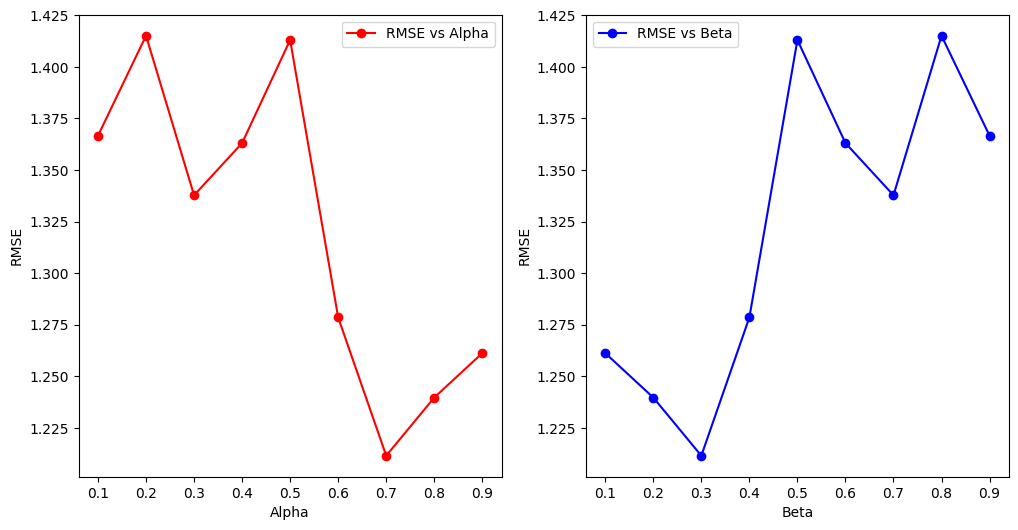

In [ ]:
# plot the RMSE corresponding to alpha and beta, color them differently and show in the legend to what value of alpha and beta they correspond to
alphas = [params[0] for params in params_list]
betas = [params[1] for params in params_list]

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot RMSEs against alphas and betas separately
axs[0].plot(alphas, RMSEs, 'ro-', label='RMSE vs Alpha')
axs[1].plot(betas, RMSEs, 'bo-', label='RMSE vs Beta')

axs[0].set_xlabel('Alpha')
axs[0].set_ylabel('RMSE')
axs[0].legend()

axs[1].set_xlabel('Beta')
axs[1].set_ylabel('RMSE')
axs[1].legend()

plt.show()

As we can evince from the plot, the best parameters are:
* ***alpha***: 0.7
* ***beta***: 0.3

Now we can train the model on our model using the best parameters (the reason why we are using a mask to filter out some values is explained in the previous section):

In [ ]:
prediction_matrix_100k_movie_cold_start, _, _, _, _, _, _, _, less_10_mask = compute_full_rating_matrix_movie_cold_start(train100k_matrix, film100k_df, movie_vectors100k, item_hidden_100k, plots100k, embeddings_100k, alpha=0.7, beta=0.3)

test_mask = (test100k_matrix != 0).astype(int)
test_mask_np = np.where(test_mask == 1)

mask_merged = np.logical_and(less_10_mask, test_mask)

rmse_res = compute_rmse(prediction_matrix_100k_movie_cold_start[mask_merged], test100k_matrix[mask_merged])
print(f"RMSE for train set: {rmse_res}\n")

Computing similarity matrix...


  0%|          | 0/1681 [00:00<?, ?it/s]

Similarity matrix computed.
Average movie ratings computed.
Computing predictions...


  0%|          | 0/1682 [00:00<?, ?it/s]

Predictions computed.
RMSE for train set: 1.127298894925494



# **JOIN THE METHODS**

This section is dedicated to joining all the matrices previously computed.



The last thing we need to do it to join the three prediction matrices:
* the one obtained from ALS ($\hat{R}^{s1}$)
* the one obtained when addressing user cold start ($\hat{R}^{s2}$)
* the one obtained when addressing movie cold start ($\hat{R}^{s3}$)

The formula for joining the results is the following:

$$
R(a, i) = \alpha \hat{R}^{s1}_{(a, i)} + \beta \frac{\hat{R}^{s2}_{(a, i)} + \hat{R}^{s3}_{(a, i)}}{2}
$$

Where $α + β = 1$, and $\hat{R}^{s1}_{(a, i)}$, $\hat{R}^{s2}_{(a, i)}$, $\hat{R}^{s3}_{(a, i)}$ respectively denotes Predicted rating for movie $i$ by user $a$ in step 1, 2, 3.

Then we also need a function to predict the rating of a specific movie by a specific user:

In [ ]:
def predict_ratings(R_1, R_2, R_3, correct_mask_R3, alpha, beta):
    """
    Predict ratings using the formula: R̂(a,i) = αR̄^1(a,i) + β·(R̄^2(a,i) + R̄^3(a,i))/2

    Parameters:
    -----------
    R_1, R_2, R_3 : numpy arrays or scipy sparse matrices
        The three rating components
    correct_mask_R3 : numpy array or scipy sparse matrix
        The mask indicating which elements of R_3 are correct
    alpha, beta : float
        The weights to combine the ratings

    Returns:
    --------
    numpy array or scipy sparse matrix
        The predicted ratings
    """
    # Ensure matrices are in the right format for efficient operations
    if not isinstance(R_1, csr_matrix):
        R_1 = csr_matrix(R_1)
    if not isinstance(R_2, csr_matrix):
        R_2 = csr_matrix(R_2)
    if not isinstance(R_3, csr_matrix):
        R_3 = csr_matrix(R_3)

    R_3[~correct_mask_R3] = 0
    R_2[~correct_mask_R3] *= 2

    # Apply the formula
    R_23_avg = (R_2 + R_3) / 2
    predicted = alpha * R_1 + beta * R_23_avg

    # transform predicted in numpy array
    predicted = np.array(predicted.todense())

    return predicted

Now that we have defined most of the things we will need to do the optimization we just need to assign the variable to the rating matrix you want to use. Then we perform the training and evaluate the RMSE.

In [ ]:
# assign what you want.
R_1=R1_100k
R_2=R2_100k
R_3=R3_100k
correction_mask = R3_correct_mask

## Sanity check
We perform some quick sanity checking to visually see if the rating of the matrix actually makes sense (all the values need to be between 1 and 5). Moreover we can quicky check if the computed rmse for the various prediction makes sense (the RMSE of the 3 prediction matrices should be between 0.5 and 2. Any value above 2 is pretty much a dumb extimation since if we had a matrix full of 3 the mean RMSE should be approximately 2).

In [ ]:
print(R_1)
print(f'max: {R_1.max()}, min: {R_1.min()}')

[[4.15026381 3.17361087 2.57040717 ... 1.         1.         1.14428627]
 [4.10318708 3.10781342 2.44895268 ... 1.         1.         1.        ]
 [3.33522878 2.54433409 2.34946581 ... 1.         1.         1.        ]
 ...
 [4.06565444 3.21682976 2.87703948 ... 1.         1.         1.0040072 ]
 [4.59540917 3.77444365 2.95051353 ... 1.         1.         1.        ]
 [3.61054799 3.01311677 3.73098943 ... 1.         1.         1.        ]]
max: 5.0, min: 1.0


In [ ]:
print(R_2)
print(f'max: {R_2.max()}, min: {R_2.min()}')

[[4.47543299 3.09280118 2.72393721 ... 2.50407579 3.62732509 3.2531331 ]
 [3.29056509 3.04345938 3.11118233 ... 2.68937049 3.81261978 3.4384278 ]
 [2.60158098 1.56011592 1.51515601 ... 1.55582233 2.67907163 2.30487964]
 ...
 [3.96605268 3.94136415 3.58465659 ... 2.94117647 4.06442577 3.69023379]
 [4.54421164 4.50356844 3.95959836 ... 3.12559618 4.24884548 3.8746535 ]
 [3.43483647 3.68833224 3.32775507 ... 2.33634067 3.45958997 3.08539799]]
max: 5.0, min: 1.0


In [ ]:
print(R_3)
print(f'max: {R_3.max()}, min: {R_3.min()}')

[[1.76776246 1.         1.         ... 2.41447126 3.91320014 1.        ]
 [1.76776246 1.         1.         ... 1.         1.         1.        ]
 [1.76776246 1.         1.         ... 1.         1.         1.        ]
 ...
 [1.76776246 1.         1.         ... 1.         1.         1.        ]
 [1.76776246 1.         1.         ... 1.         1.         1.        ]
 [1.76776246 1.         1.         ... 1.         1.         1.        ]]
max: 5.0, min: 1.0


In [ ]:
rmse = compute_rmse(R_1, test100k_matrix)
print(f'RMSE for R_1: \n{rmse}')

RMSE for R_1: 
1.054843430700217


In [ ]:
rmse = compute_rmse(R_2, test100k_matrix)
print(f'RMSE for R_2: \n{rmse}')

RMSE for R_2: 
1.0579500865470957


In [ ]:
rmse = compute_rmse(R_3[R3_correct_mask], test100k_matrix[R3_correct_mask])
print(f'RMSE for R_3: \n{rmse}')

RMSE for R_3: 
0.947065633028208


## Optimization

Now we need to optimize the parameters $\alpha$ and $\beta$. We will use grid optimization and will iterate for values in the $0.0-1.0$ range for both.

In [ ]:
def grid_search_optimization(true_ratings, R_1, R_2, R_3, correction_mask, step=0.1):
    """
    Perform grid search to find optimal alpha and beta values
    that minimize RMSE, with constraint alpha + beta = 1.

    Parameters:
    -----------
    true_ratings : numpy array or scipy sparse matrix
        The matrix containing true ratings
    R_1, R_2, R_3 : numpy arrays or scipy sparse matrices
        The three rating components used in the formula
    step : float, default=0.1
        The step size for alpha and beta values

    Returns:
    --------
    tuple
        (best_alpha, best_beta, best_rmse)
    """
    total_start_time = time.time()

    # Ensure constraint alpha + beta = 1
    alpha_values = np.arange(0, 1.01, step)
    beta_values = 1 - alpha_values

    results = []
    best_rmse = float('inf')
    best_alpha = 0
    best_beta = 0

    print(f"Starting grid search with {len(alpha_values)} configurations...")

    # Progress bar for better visualization
    for i, (alpha, beta) in enumerate(tqdm(zip(alpha_values, beta_values), total=len(alpha_values))):
        # Calculate predicted ratings
        predicted_ratings = predict_ratings(R_1, R_2, R_3, correction_mask, alpha, beta)

        # Calculate RMSE
        rmse = compute_rmse(predicted_ratings, true_ratings)
        results.append((alpha, beta, rmse))

        # Update best parameters if RMSE is lower
        if rmse < best_rmse:
            best_rmse = rmse
            best_alpha = alpha
            best_beta = beta

        print(f"Configuration {i+1}/{len(alpha_values)}: alpha={alpha:.1f}, beta={beta:.1f}, RMSE={rmse:.4f}")

    total_elapsed_time = time.time() - total_start_time
    print(f"\nGrid search completed in {total_elapsed_time:.2f} seconds")
    print(f"Best parameters: alpha={best_alpha:.2f}, beta={best_beta:.2f}, RMSE={best_rmse:.4f}")

    # Plot results
    plot_results(results)

    return best_alpha, best_beta, best_rmse

def plot_results(results):
    """
    Plot RMSE values for different alpha and beta combinations.

    Parameters:
    -----------
    results : list of tuples
        List containing (alpha, beta, rmse) tuples
    """
    alpha_values = [r[0] for r in results]
    rmse_values = [r[2] for r in results]

    plt.figure(figsize=(10, 6))
    plt.plot(alpha_values, rmse_values, 'o-', linewidth=2)
    plt.xlabel('Alpha (Beta = 1 - Alpha)')
    plt.ylabel('RMSE')
    plt.title('RMSE vs. Alpha/Beta Parameters')
    plt.grid(True)

    # Add annotation for best point
    best_idx = np.argmin(rmse_values)
    best_alpha = alpha_values[best_idx]
    best_rmse = rmse_values[best_idx]

    plt.annotate(f'Best: α={best_alpha:.2f}, RMSE={best_rmse:.4f}',
                 xy=(best_alpha, best_rmse),
                 xytext=(best_alpha+0.1, best_rmse+0.01),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5))

    plt.tight_layout()
    plt.show()

Starting optimization...
Starting grid search with 11 configurations...


  0%|          | 0/11 [00:00<?, ?it/s]

Configuration 1/11: alpha=0.0, beta=1.0, RMSE=1.0571
Configuration 2/11: alpha=0.1, beta=0.9, RMSE=1.0426
Configuration 3/11: alpha=0.2, beta=0.8, RMSE=1.0311
Configuration 4/11: alpha=0.3, beta=0.7, RMSE=1.0228
Configuration 5/11: alpha=0.4, beta=0.6, RMSE=1.0176
Configuration 6/11: alpha=0.5, beta=0.5, RMSE=1.0158
Configuration 7/11: alpha=0.6, beta=0.4, RMSE=1.0172
Configuration 8/11: alpha=0.7, beta=0.3, RMSE=1.0218
Configuration 9/11: alpha=0.8, beta=0.2, RMSE=1.0297
Configuration 10/11: alpha=0.9, beta=0.1, RMSE=1.0408
Configuration 11/11: alpha=1.0, beta=0.0, RMSE=1.0548

Grid search completed in 8.21 seconds
Best parameters: alpha=0.50, beta=0.50, RMSE=1.0158


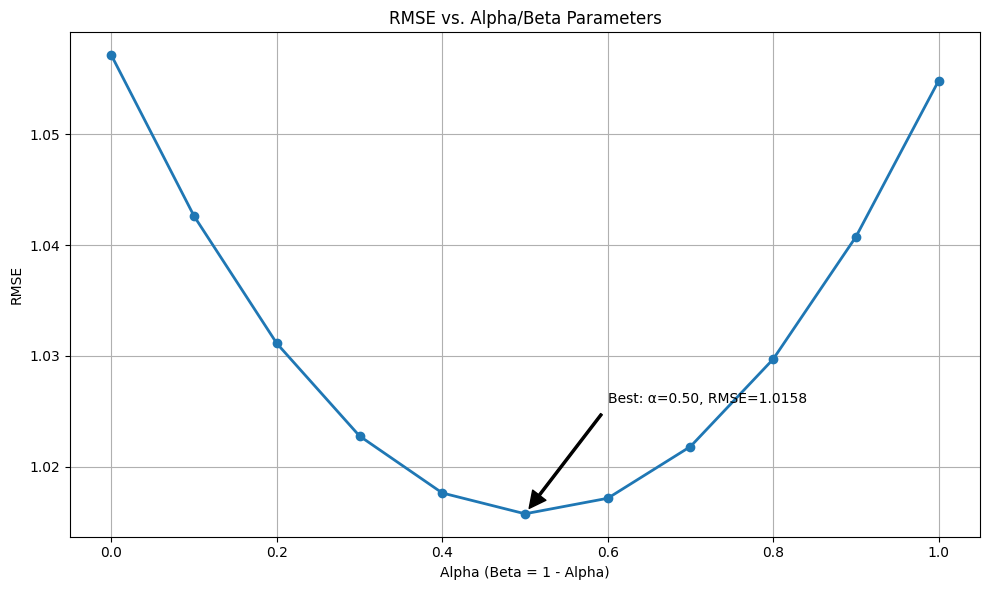

Optimal parameters: alpha=0.50, beta=0.50, RMSE=1.0158


In [ ]:
print("Starting optimization...")
best_alpha, best_beta, best_rmse = grid_search_optimization(test100k_matrix, R_1, R_2, R_3, correction_mask, step=0.1)
print(f"Optimal parameters: alpha={best_alpha:.2f}, beta={best_beta:.2f}, RMSE={best_rmse:.4f}")

As we can see, the best parameter for the 100K dataset is obtained with:

$$\alpha = 0.5, \beta=0.5$$

leading to an RMSE of 1.0158. This is a great result for our prediction pipeline!

In [ ]:
R1_m = R1_1M
R2_m = R2_1m
R3_m = R3_1m
correction_mask_m = R3_correct_mask_1m

Starting optimization...
Starting grid search with 11 configurations...


  0%|          | 0/11 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


Configuration 1/11: alpha=0.0, beta=1.0, RMSE=0.9780


/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


...

Configuration 9/11: alpha=0.8, beta=0.2, RMSE=0.9258


/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


Configuration 10/11: alpha=0.9, beta=0.1, RMSE=0.9342


/usr/local/lib/python3.11/dist-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


Configuration 11/11: alpha=1.0, beta=0.0, RMSE=0.9458

Grid search completed in 150.07 seconds
Best parameters: alpha=0.60, beta=0.40, RMSE=0.9189


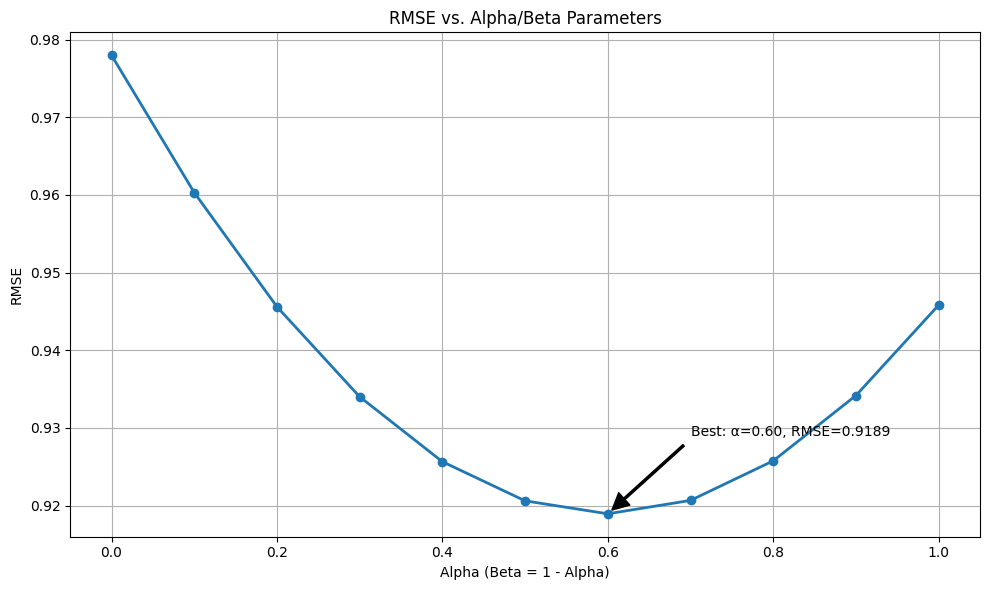

Optimal parameters: alpha=0.60, beta=0.40, RMSE=0.9189


In [ ]:
print("Starting optimization...")
best_alpha, best_beta, best_rmse = grid_search_optimization(test1m_matrix, R1_m, R2_m, R3_m, correction_mask_m, step=0.1)
print(f"Optimal parameters: alpha={best_alpha:.2f}, beta={best_beta:.2f}, RMSE={best_rmse:.4f}")

As we can see, the best parameter is obtained with:

$$\alpha = 0.6, \beta=0.4$$

leading to an RMSE of 0.9189. This is a great result for our prediction pipeline!